# <a id='toc1_'></a>[Auswertungen: kolorektale Krebserkrankungen](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Auswertungen: kolorektale Krebserkrankungen](#toc1_)    
  - [📆 Datenstand](#toc1_1_)    
  - [⚙️ Teildatensatz](#toc1_2_)    
  - [Fallzahlen](#toc1_3_)    
    - [Fallzahlen C18-C20 nach Viersteller](#toc1_3_1_)    
  - [OP](#toc1_4_)    
    - [keine Operation erfolgt bei C18 mit T_p > 0](#toc1_4_1_)    
    - [Stratifizierung für keine OP erfolgt](#toc1_4_2_)    
  - [OPS](#toc1_5_)    
    - [OPS 5-4xx nach Diagnose](#toc1_5_1_)    
      - [C18](#toc1_5_1_1_)    
      - [C20](#toc1_5_1_2_)    
    - [Vergleich laparoskopisch vs offen](#toc1_5_2_)    
    - [ Verteilung OPS 5-455 bei C18](#toc1_5_3_)    
    - [ Verteilung OPS 5-484 bei C20](#toc1_5_4_)    
    - [Details OPS 5-455](#toc1_5_5_)    
      - [Kombination von Gruppen](#toc1_5_5_1_)    
      - [Anteil Robotik](#toc1_5_5_2_)    
      - [Ileozökalresektion](#toc1_5_5_3_)    
      - [rechte Hemikolektomie](#toc1_5_5_4_)    
      - [Sigmaresektion](#toc1_5_5_5_)    
  - [Lokalisation (Fernmetastasen) für C18](#toc1_6_)    
    - [nach M](#toc1_6_1_)    
    - [Anteil FM Lokalisation Leber bei M1](#toc1_6_2_)    
    - [Behandlungsverlauf](#toc1_6_3_)    
    - [Erste Behandlung bei Leber FM](#toc1_6_4_)    
    - [OPS wenn Erstbehandlung OPS](#toc1_6_5_)    
  - [Rezidive](#toc1_7_)    
    - [Verteilung OP in 2020](#toc1_7_1_)    
    - [M Stadium und Vitalstatus bei Tumoren ohne Therapie und pT](#toc1_7_2_)    
    - [R Status](#toc1_7_3_)    
      - [davon: Verteilung nur R0](#toc1_7_3_1_)    
  - [Behandlung innerhalb von 6 Wochen](#toc1_8_)    
    - [Zeitlicher Abstand der Behandlungen](#toc1_8_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp, const
from pandas_plots.hlp import add_bitmask_label
import duckdb as ddb

from mod.filters import *

hlp.show_package_version()
# hlp.show_package_version(["pygwalker", "plotly"])

os.environ['THEME']='dark'
os.environ['RENDERER']='svg'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
# file_db_clin = dir_db/'2026-03-04_data_clin.duckdb'
# file_db_clin = dir_db/'fake_data_clin.duckdb'
if not file_db_clin.exists():
    raise FileNotFoundError(file_db_clin)

if not os.path.exists(".local"):
    os.makedirs(".local")

# hlp.setup_rendering(True)

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.5.0 | 📦 pandas-plots: 1.4.3


In [41]:
con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

## <a id='toc1_1_'></a>[📆 Datenstand](#toc0_)

In [42]:
sql.print_meta(file_db_clin)

database file:           2025-11-11_data_clin.duckdb
data tag:                v2.3
last kkr data import:    2025-09-30
sql table created:       2025-11-11 11:52:01
doi:                     10.18444/5.03.01.0005.0021.0002
document created:        2026-04-27 21:55:44


## <a id='toc1_2_'></a>[⚙️ Teildatensatz](#toc0_)
- Filter für gültige Fälle: (dieser Filter ist für **alle** Analysen gesetzt)
  - `z_dy` (Diagnosejahr) in 2020-2024
  - `z_icd10_3d` (Primärdiagnose) in `C18`-`C20`

In [43]:
# # * settings
FILTERS_C18 = ("z_icd10_3d in ('C18')", "nur C18")
FILTERS_C1803 = ("z_icd10 in ('C18.0','C18.1','C18.2','C18.3')", "ICD C18.0-3")
FILTERS_OPS_54 = ("left(Code,3) in ('5-4')", "OPS 5-4")
FILTERS_OPS_545 = ("""--sql
    (
        left(Code,7) in ('5-455.2', '5-455.4', '5-455.7')
    )""", "OPS 5-45xx")

# # OR left(Code,5) in ('5-987')

FILTERS_OPS_HEMI = ("""--sql
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )""", "OPS hemi")

FILTER_OPS_SIG = ("""--sql
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )""", "OPS sigma")

FILTERS_2020 = ("z_dy = 2020", "DJ 2020")
FILTERS_HEP = ("""--sql
    z_tum_id in (
        select distinct tum.z_tum_id
        from Tumor tum
        left join Diagnose_Fernmetastase dfm on tum.z_tum_id = dfm.z_tum_id
        left join Folgeereignis_Fernmetastase ffm on tum.z_tum_id = ffm.z_tum_id
        where (dfm.Lokalisation = 'HEP' or ffm.Lokalisation = 'HEP')
    )""", "Tumor mit HEP Lokalisation in FM Diagnose oder Verlauf")

In [44]:
# # # ! depr
# # * co-li-sy-st
# db_treatment_first_co_li_sy_st = (con.sql("""--sql
#         -- all tum_id w/ a first_treatment variable that codes the values as bitmask (colon = 1, liver = 2, syst = 4 etc)
#         -- do not code a set like "has x but not y" for ops since there are overlaps
#         -- use bit operation '&' to filter: WHERE treatment_first_co_li_sy_st & 4 = 4;
#         select  z_tum_id, 
#             max(colon) + max(liver) * 2 + max(syst) * 4 + max(st) * 8 as treatment_first_co_li_sy_st
#         from (
#             select 
#                 tu.z_tum_id,
#                 case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-455','5-484','5-485') then 1 else 0 end as colon, 
#                 case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-501', '5-502', '5-503') then 1 else 0 end as liver,
#                 case when tu.z_first_treatment = 'sy' then 1 else 0 end as syst,
#                 case when tu.z_first_treatment = 'st' then 1 else 0 end as st,
#             from Tumor tu 
#             left join SYST syst on tu.z_tum_id = syst.z_tum_id
#             left join OP op on tu.z_tum_id = op.z_tum_id
#             left join OPS ops on op.OPId = ops.OP_TypId
#         ) t
#         group by z_tum_id
#     """)
#     .add_bitmask_label(bitmask_col='treatment_first_co_li_sy_st', labels=['co', 'li', 'sy', 'st'], con=con)
#     .project("z_tum_id, treatment_first_co_li_sy_st_label as treatment_first_co_li_sy_st")
# )

# # tbl.descr_db(db_treatment_first_co_li_sy_st, 'treatment_first_co_li_sy_st')

In [45]:
# # # * Leber Gruppen
# db_liver_grps = (con.sql("""--sql
#         select  z_tum_id, 
#             max(g1) + max(g2) * 2 + max(g3) * 4 + max(g4) * 8 + max(g5) * 16 + max(g6) * 32 + max(g7) * 64 + max(g8) * 128 as liver_grps
#         from (
#             select 
#                 tu.z_tum_id,
#                 case when substr(ops.Code,1,8) in ('5-455.21') then 1 else 0 end as g1,
#                 case when substr(ops.Code,1,8) in ('5-455.25') then 1 else 0 end as g2,
#                 case when substr(ops.Code,1,8) in ('5-455.27') then 1 else 0 end as g3,
#                 case when substr(ops.Code,1,8) in ('5-455.31') then 1 else 0 end as g4,
#                 case when substr(ops.Code,1,8) in ('5-455.35') then 1 else 0 end as g5,
#                 case when substr(ops.Code,1,8) in ('5-455.37') then 1 else 0 end as g6,
#                 case when substr(ops.Code,1,8) in ('5-455.41') then 1 else 0 end as g7,
#                 case when substr(ops.Code,1,8) in ('5-455.45') then 1 else 0 end as g8
#             from Tumor tu
#             left join SYST syst on tu.z_tum_id = syst.z_tum_id
#             left join OP op on tu.z_tum_id = op.z_tum_id
#             left join OPS ops on op.OPId = ops.OP_TypId
#         ) t
#         group by z_tum_id
#     """)
#     .add_bitmask_label(bitmask_col='liver_grps', labels=['g21', 'g25', 'g27', 'g31', 'g35', 'g37', 'g41', 'g45'], con=con)
#     .project("z_tum_id, liver_grps_label as liver_grps")
# )
# # tbl.descr_db(db_liver_grps, 'liver_grps')

In [46]:
# con.sql("describe tumor").fetchall()

In [47]:
# # # ! depr

# # * table id and respective dates (eg. op, st, syst, bestr) are included to give a complete picture of the data
# # * first create complete dataset incl all icd10 (>4mio rows) for survey analysis, but reduce to C18C20 after
# db_allicd = (con.sql("""--sql
#     select 
#         tum.z_tum_id,
#         tum.z_kkr_label,
#         z_icd10, 
#         z_icd10_3d,-- icd10_1d,
#         z_dy,
#         z_sex,
#         z_t_p_1, z_t_c_1, z_n_p_1, z_m_pc_1, z_m_p_0,
#         coalesce(z_t_p_1, z_t_c_1) as z_t_pc_1,
#         uicc.code_1 as UICC_Stadium_p_1,
#         z_ag05, 
#         z_age,
#         --z_tum_st_count, z_tum_op_count, z_tum_sy_count,
#         dsich.name as Diagnosesicherung,

#         z_pat_id,
#         pat.Verstorben,

#         op.OPId as op_id, op.Datum_OP,
#         z_op_order, dim_op_intention.name as Intention_OP, dim_r_typ.name as OP_Lokale_Beurteilung_Residualstatus,

#         syst.SYSTId as syst_id, syst.Datum_Beginn_SYST,
#         dim_syst_intention.name as Intention_SYST, syst.Therapieart,
        
#         st.STId as st_id, 
#         dim_st_intention.name as Intention_ST, dim_st_op_stellung.name as ST_Stellung_OP,

#         bestr.BestrahlungId as bestr_id, bestr.Datum_Beginn_Bestrahlung,
        
#         folge.FolgeereignisId as folge_id, folge.Datum_Folgeereignis,
#         dim_verlauf_lokal.name as Folge_Verlauf_Lokaler_Tumorstatus,

#         dim_fm_lokalisation.name as FM_Lokalisation,
        
#         RASMutation,
#         RektumAbstandAnokutanlinie,

#         z_first_treatment, 
#         z_first_treatment_after_days,
#         z_tum_st_count, z_tum_op_count, z_tum_sy_count, z_tum_fo_count,
#         (z_tum_op_count > 0) as tum_has_op,
#         db_treatment_first_co_li_sy_st.treatment_first_co_li_sy_st,
#         --db_liver_grps.liver_grps,
#         z_last_tum_status,

#         case when z_icd10_3d in ('C18','C19','C20') then cast(true as bool) else cast(false as bool) end as 'C18C20',
#     from Tumor tum
#     join Patient pat on tum.oBDS_RKIPatientId = pat.oBDS_RKIPatientId
#     left join db_treatment_first_co_li_sy_st on tum.z_tum_id = db_treatment_first_co_li_sy_st.z_tum_id
#     --left join db_liver_grps on tum.z_tum_id = db_liver_grps.z_tum_id
#     left join dim_diagnosesicherung_clin dsich on dsich.code = Diagnosesicherung
#     left join SYST syst on tum.z_tum_id = syst.z_tum_id
#     left join ST st on tum.z_tum_id = st.z_tum_id
#     left join Bestrahlung bestr on st.STId = bestr.STId
#     left join OP op on tum.z_tum_id = op.z_tum_id
#     left join dim_tnm_uicc uicc on UICC_Stadium_p = uicc.code
#     left join Folgeereignis folge on tum.z_tum_id = folge.z_tum_id
#     left join Diagnose_Fernmetastase fm on tum.z_tum_id = fm.z_tum_id
#     left join dim_beurteilung_gesamt dim_folge_1 on Gesamtbeurteilung_Tumorstatus = dim_folge_1.code
#     left join dim_fm_lokalisation on Lokalisation = dim_fm_lokalisation.code
#     left join dim_verlauf_lokal on folge.Verlauf_Lokaler_Tumorstatus = dim_verlauf_lokal.code
#     left join dim_op_intention on op.Intention = dim_op_intention.code
#     left join dim_st_intention on st.Intention = dim_st_intention.code
#     left join dim_st_op_stellung on st.Stellung_OP = dim_st_op_stellung.code
#     left join dim_syst_intention on syst.Intention = dim_syst_intention.code
#     left join dim_r_typ on op.Lokale_Beurteilung_Residualstatus = dim_r_typ.code
#     """)
#     .filter(f"{FILTERS_DY[0]}")
# )

# # * derive colorectal dataset
# db_colon = db_allicd.filter(f"{FILTERS_C18C20[0]}")

# # tbl.descr_db(db_allicd, caption="all icd", use_preview=False)
# # tbl.descr_db(db_colon, caption="colorectal", use_preview=True)

<!-- ### <a id='toc1_2_1_'></a>[Deskriptive Statistik](#toc0_) -->

## <a id='toc1_3_'></a>[Fallzahlen](#toc0_)

### <a id='toc1_3_1_'></a>[Fallzahlen C18-C20 nach Viersteller](#toc0_)
> 💡 `C19` darf eigentlich nicht verwendet werden, wird von Krebsgesellschaft nicht akzeptiert

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [ICD10 C18-C20]:   n = 227_053   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
```

</details>

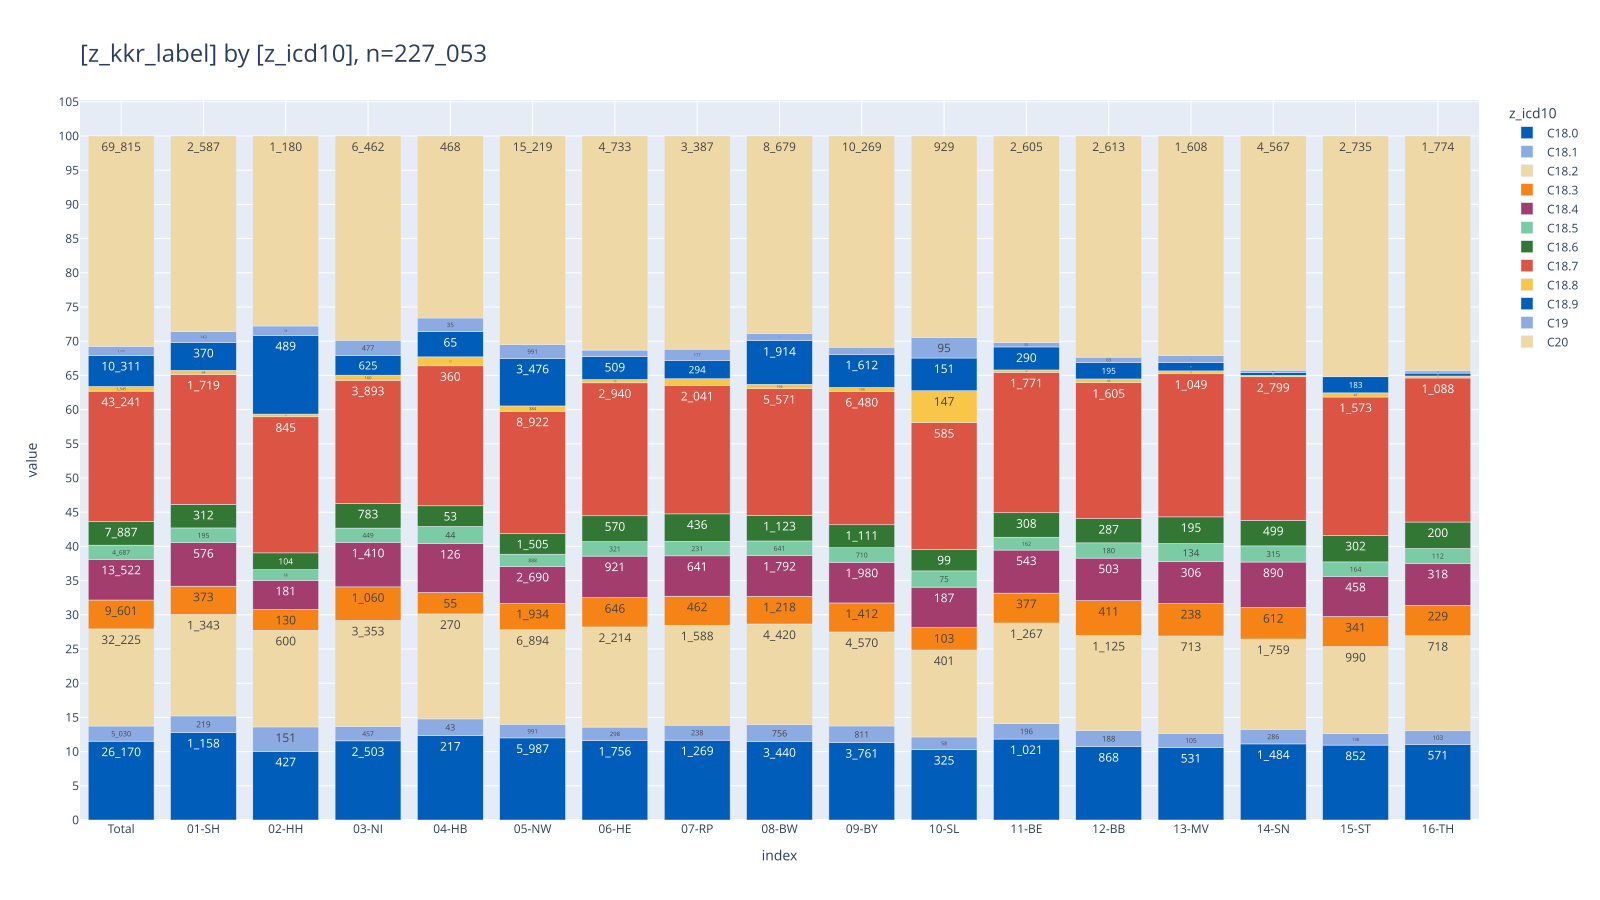

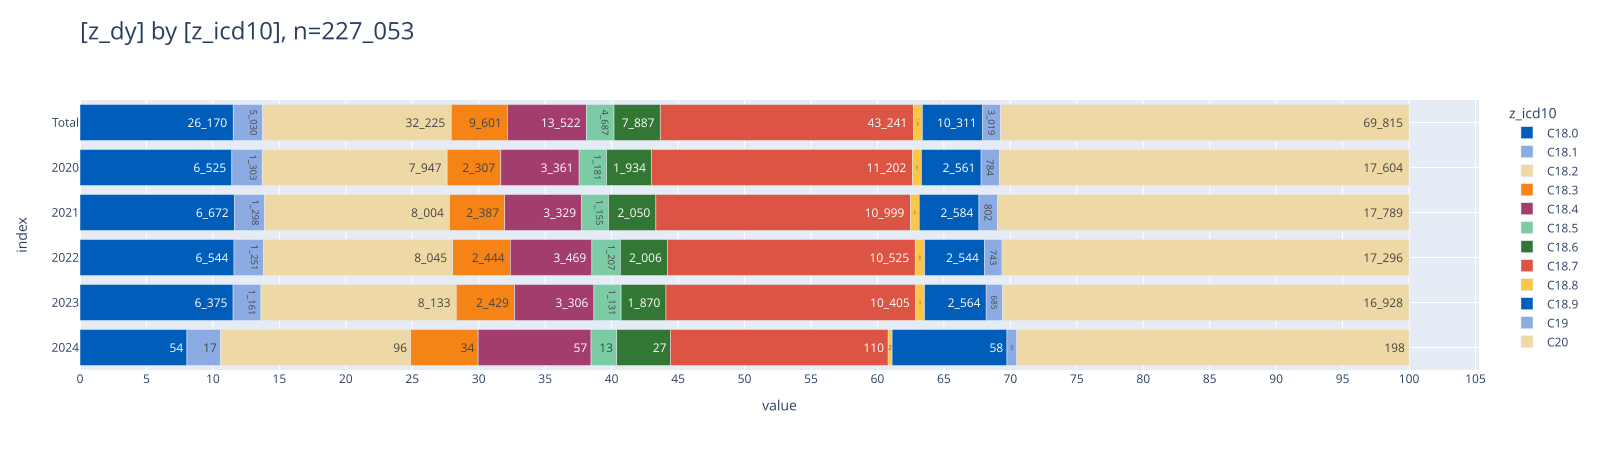

In [48]:
_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
]
filter_default = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
)

_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        z_kkr_label,
        z_icd10,
    from Tumor
    where {filter_default}
""").to_df()

_ = pls.plot_stacked_bars(
    _df[["z_kkr_label", "z_icd10"]],
    orientation="v",
    height=900,
    show_total=True,
    relative=True,
    # color_palette="Pastel",
)
_ = pls.plot_stacked_bars(
    _df[["z_dy", "z_icd10"]],
    orientation="h",
    height=450,
    show_total=True,
    relative=True,
    # color_palette="Pastel",
)


## <a id='toc1_4_'></a>[OP](#toc0_)

### <a id='toc1_4_1_'></a>[keine Operation erfolgt bei C18 mit T_p > 0](#toc0_)
> 💡 5% wäre realistisch. patho stadium müsste zwingend vorhanden sein nach OP

In [49]:

_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_TP,
    # FILTERS_2020,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        z_kkr_label,
        sum((z_tum_op_count = 0)) as cnt_tum_has_no_op,
        count(*) as cnt_tum,
        cnt_tum_has_no_op / cnt_tum as pct_tum_has_no_op,
    from Tumor
    where {_filter}
    group by all
    union
    select
        z_dy::text as z_dy,
        'Total' as z_kkr_label,
        sum((z_tum_op_count = 0)) as cnt_tum_has_no_op,
        count(*) as cnt_tum,
        cnt_tum_has_no_op / cnt_tum as pct_tum_has_no_op,
    from Tumor
    where {_filter}
    group by all
    union
    select
        'Total' as z_dy,
        z_kkr_label,
        sum((z_tum_op_count = 0)) as cnt_tum_has_no_op,
        count(*) as cnt_tum,
        cnt_tum_has_no_op / cnt_tum as pct_tum_has_no_op,
    from Tumor
    where {_filter}
    group by all
    union
    select
        'Total' as z_dy,
        'Total' as z_kkr_label,
        sum((z_tum_op_count = 0)) as cnt_tum_has_no_op,
        count(*) as cnt_tum,
        cnt_tum_has_no_op / cnt_tum as pct_tum_has_no_op,
    from Tumor
    where {_filter}
    group by all
    """)
    .to_df()
    [["z_dy", "z_kkr_label","pct_tum_has_no_op"]]
)

_df

tbl.pivot_df(
    _df,
    total_axis="",
    precision=1,
    show_as_pct=True,
    pct_axis="",
    data_bar_axis="",
    heatmap_axis="xy",
    kpi_mode="min_max_x",
    # total_exclude=True,
    # kpi_mode="rag_abs",
    # kpi_rag_list=[.95, .8]
    swap=True,
    font_size_th=12,
    font_size_td=11,
    image_scale="60%",
)


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 154_219  (67.9%) ░░░░░░░░░░████████████████████
└ [t_p = 1-4]:     n = 119_780  (52.8%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C18')
and z_t_p_1 in ('1','2','3','4')
```

</details>

<!-- SCALE-60% -->

z_dy,2020,2021,2022,2023,2024,Total
z_kkr_label,,,,,,
01-SH,10.7% ⬜,17.1% ⬜,18.4% ⬜,14.5% ⬜,0 🟩,15.2% ⬜
02-HH,13.9% ⬜,14.2% ⬜,12.1% ⬜,13.1% ⬜,0 🟩,13.3% ⬜
03-NI,25.5% ⬜,23.7% ⬜,26.7% 🟥,34.8% 🟥,0 🟩,27.4% 🟥
04-HB,12.1% ⬜,10.3% ⬜,12.4% ⬜,15.9% ⬜,0 🟩,12.6% ⬜
05-NW,28.6% 🟥,21.8% ⬜,22.2% ⬜,26.3% ⬜,0 🟩,24.7% ⬜
06-HE,23.3% ⬜,26.6% 🟥,26.5% ⬜,27.2% ⬜,32.0% ⬜,26.0% ⬜
07-RP,20.4% ⬜,20.6% ⬜,25.8% ⬜,29.9% ⬜,0 🟩,23.9% ⬜
08-BW,20.5% ⬜,19.8% ⬜,25.0% ⬜,22.4% ⬜,0 🟩,21.9% ⬜
09-BY,15.4% ⬜,18.5% ⬜,16.9% ⬜,19.8% ⬜,43.4% 🟥,17.8% ⬜


### <a id='toc1_4_2_'></a>[Stratifizierung für keine OP erfolgt](#toc0_)
- `categ_treat`
  - `1-op` - OP dokumentiert
  - `2-noop-sy-st` - keine OP dokumentiert, aber ST oder SYST
  - `3-noop-nosy-nost` - keine Behandlung dokumentiert

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 154_219  (67.9%) ░░░░░░░░░░████████████████████
└ [t_p = 1-4]:     n = 119_780  (52.8%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C18')
and z_t_p_1 in ('1','2','3','4')
```

</details>

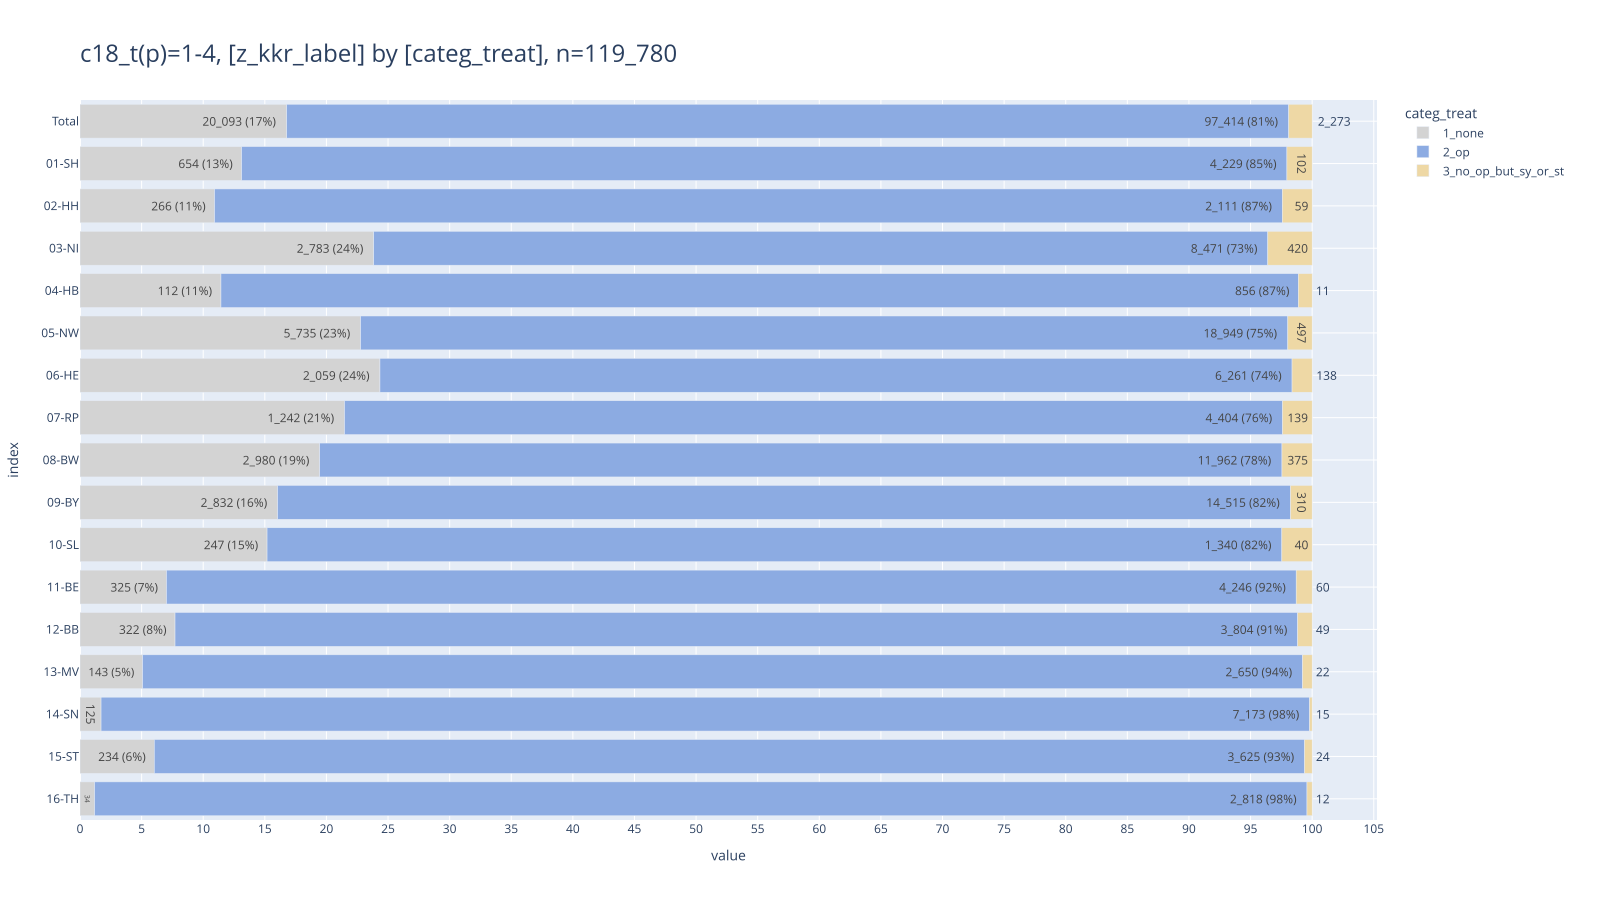

In [50]:
_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_TP,
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)
_df = (con.sql(f"""--sql
    select
        z_kkr_label,
        case 
            when z_tum_op_count + z_tum_sy_count + z_tum_st_count = 0 then '1_none'
            when z_tum_op_count > 0 then '2_op'
            when z_tum_sy_count > 0 or z_tum_st_count > 0 then '3_no_op_but_sy_or_st'
            else '9-unknown' end as categ_treat
    from Tumor
    where {_filter}
    """)
    .to_df()
)
# display(_df)


_=pls.plot_stacked_bars(
    _df,
    relative=True,
    show_total=True,
    orientation="h",
    height=900,
    show_pct_bar=True,
    caption="c18_t(p)=1-4",
    first_col_grey=True,
    color_palette=const.PALETTE_RKI2,
)
# todo hier kann weiter aufgeteilt werden

## <a id='toc1_5_'></a>[OPS](#toc0_)


### <a id='toc1_5_1_'></a>[OPS 5-4xx nach Diagnose](#toc0_)
- gezählt sind OPS Angaben, nicht Tumore

<br>

In [51]:
def show_ops(filter: str, caption: str,):
    db_ops_kkr = con.sql(f"""--sql
        select
                z_dy::text as z_dy,
                z_kkr_label,
                ops.Code as ops_code,
                count(distinct OPSId) as cnt_ops,
                dim_ops.name as ops_name,
        from Tumor tum
        left join OP op on tum.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join (select code as code_, name from dim_ops) as dim_ops on dim_ops.code_ = ops.Code
        where {filter}
        group by ops_code, z_kkr_label, ops_name, z_dy
        """)
    # tbl.descr_db(db_ops_kkr, "ops_kk")

    # if print_table:
    print("Anzahl verschiedene ops_codes: ",db_ops_kkr.count("distinct ops_code").fetchone()[0])
    db_ops_kkr.aggregate("ops_code || ' - ' || ops_name as ops, sum(cnt_ops)::int as cnt_ops").order("cnt_ops desc").limit(10).show(max_width=145)
    
    # hlp.print_filter(filter, show_as_details=True)

    display(_ = pls.plot_stacked_bars(
        db_ops_kkr.project("z_kkr_label, ops_code, cnt_ops").to_df(),
        # orientation="h",
        relative=True,
        top_n_color=10,
        sort_values_color=True,
        caption=caption,
        # color_palette=const.PALETTE_RKI2,
    ))
    display(_ = pls.plot_stacked_bars(
        db_ops_kkr.project("z_dy, ops_code, cnt_ops").to_df(),
        orientation="h",
        relative=True,
        height=400,
        top_n_color=10,
        sort_values_color=True,
        caption=caption,
        # color_palette="Pastel",
    ))

#### <a id='toc1_5_1_1_'></a>[C18](#toc0_)

<!-- START_TOKEN -->

counts: distinct OPSId
---
n = 3_147_760                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_094_975  (98.3%) ░█████████████████████████████
└ [ICD10 C18-C20]:   n = 390_274  (12.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [nur C18]:         n = 253_295   (8.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [OPS 5-4]:         n = 172_498   (5.5%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C18')
and left(Code,3) in ('5-4')
```

</details>

Anzahl verschiedene ops_codes:  14492
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-455.41 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts]… │   24976 │
│ 5-455.45 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts]… │   15845 │
│ 5-469.20 - Andere Operationen am Darm: Adhäsiolyse: Offen chirurgisch               

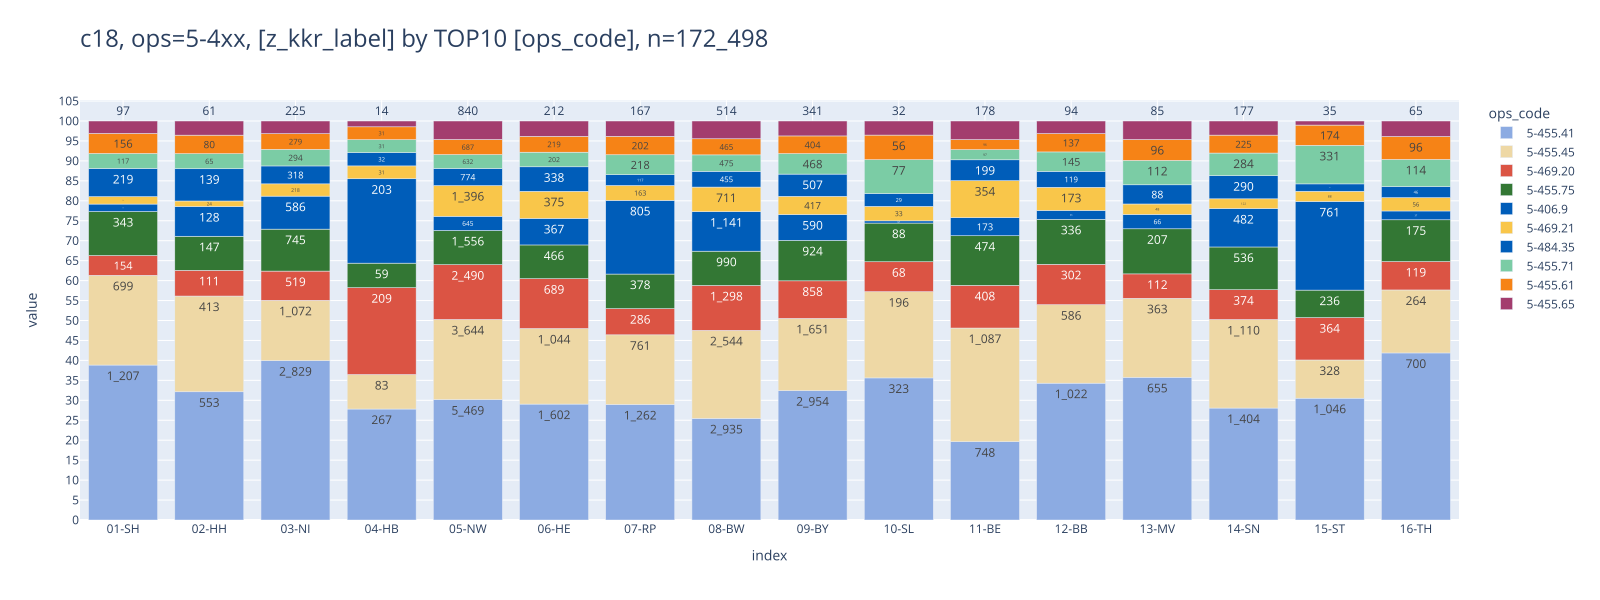

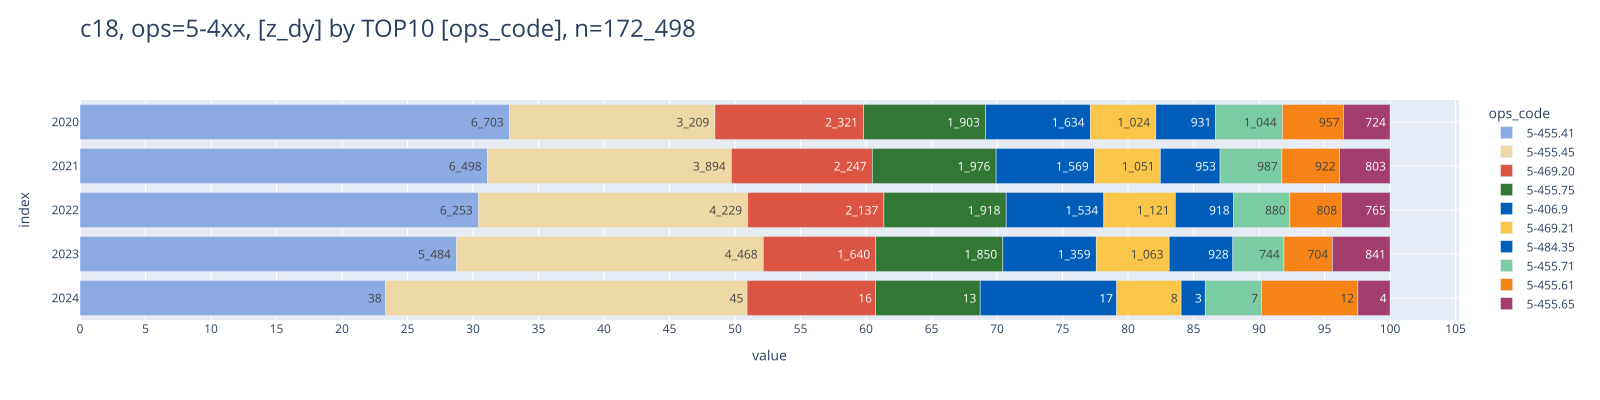

In [52]:
_filters_ops1 = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_OPS_54,
]
_filter_ops1 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    filters=_filters_ops1,
    distinct_metric="OPSId",
    first_n_filter_apply_to_rows=0,
)

show_ops(_filter_ops1,"c18, ops=5-4xx")


#### <a id='toc1_5_1_2_'></a>[C20](#toc0_)

<!-- START_TOKEN -->

counts: distinct OPSId
---
n = 3_147_760                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_094_975  (98.3%) ░█████████████████████████████
└ [ICD10 C18-C20]:   n = 390_274  (12.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [ICD10 C20]:       n = 133_352   (4.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [OPS 5-4]:          n = 88_029   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C20')
and left(Code,3) in ('5-4')
```

</details>

Anzahl verschiedene ops_codes:  10645
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-484.55 - Rektumresektion unter Sphinktererhaltung: Tiefe anteriore Resektion: Laparoskopisch mit Anastomose                       │    9580 │
│ 5-462.1 - Anlegen eines Enterostomas (als protektive Maßnahme) im Rahmen eines anderen Eingriffs: Ileostoma                         │    9505 │
│ 5-484.35 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Laparoskop

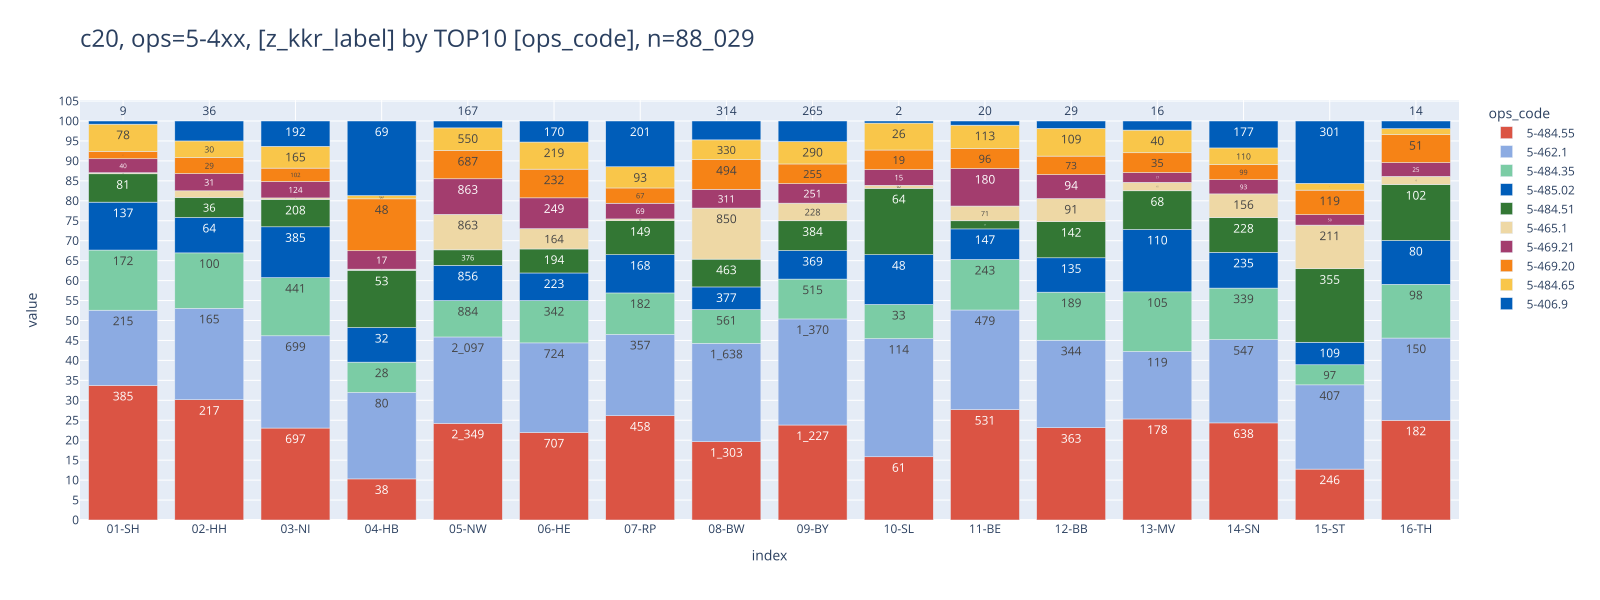

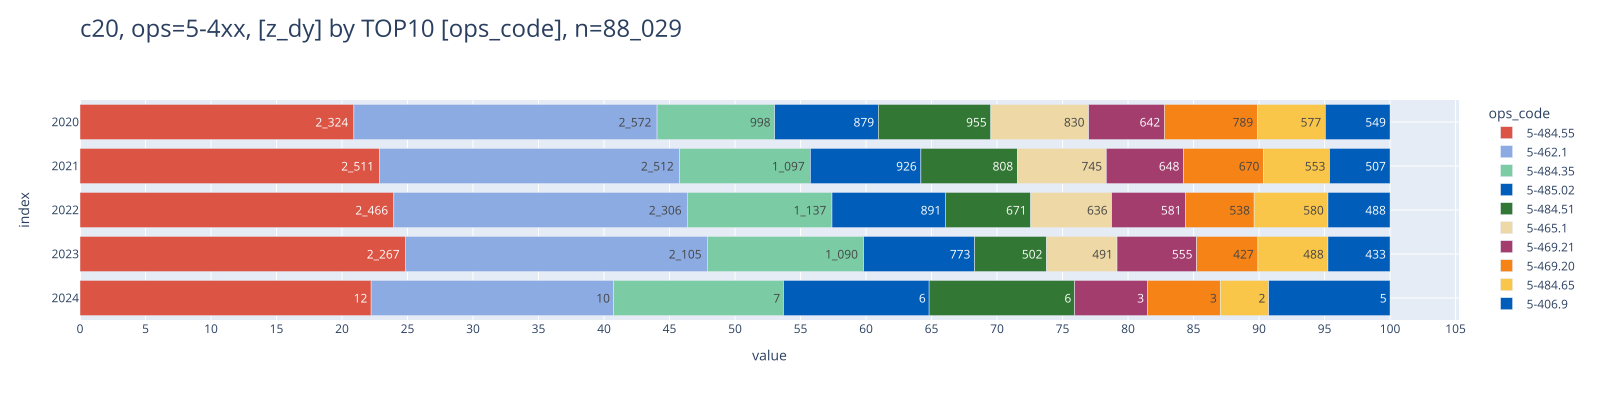

In [53]:
_filters_ops3 = [
    FILTERS_DY,
    FILTERS_C18C20,
    ("z_icd10_3d in ('C20')", "ICD10 C20"),
    FILTERS_OPS_54,
]
_filter_ops3 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    # query="from Tumor tum left join OP op on tum.z_tum_id = op.z_tum_id left join OPS ops on op.OPId = ops.OP_TypId",
    filters=_filters_ops3,
    distinct_metric="OPSId",
    first_n_filter_apply_to_rows=0,
)

show_ops(_filter_ops3, "c20, ops=5-4xx")

### <a id='toc1_5_2_'></a>[Vergleich laparoskopisch vs offen](#toc0_)
- gezählt sind Tumore
- im Filter: 
  - `C18.0-3`
  - nur Tumore, denen entweder `5-455.41` oder `5-455.45` zugeordnet ist (ℹ️ kein Tumor hat beide OPS)
- Metrik: Anteil Tumore mit `5-455.41` (offen) an allen Tumoren im Filter

In [54]:
# # todo OK top 30 zum ausfiltern
# _filters = [
#     FILTERS_DY,
#     FILTERS_C18C20,
#     FILTERS_C1803,
#     FILTERS_OPS_54,
# ]
# _filter = hlp.get_duckdb_filter_n(
#     con=con,
#     query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
#     filters=_filters,
#     distinct_metric="z_tum_id",
#     first_n_filter_apply_to_rows=0,
#     show_filter=False,
# )

# con.sql(f"""--sql
#     select
#         Code,
#         name,
#         count(*) as cnt,
#     from Tumor tum
#     left join OP op on tum.z_tum_id = op.z_tum_id
#     left join OPS ops on op.OPId = ops.OP_TypId
#     left join (select code as code_, name from dim_ops) as dim_ops on dim_ops.code_ = ops.Code
#     where {_filter}
#     group by all
#     order by cnt desc
#     limit 30
#     """).to_df().to_csv("top_30_ops_c1803.csv", index=False, sep=";")
# # .show(max_rows=30)

In [55]:

_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C1803,
    ("Code in ('5-455.41', '5-455.45')", "ops=5-455.4xx"),
]
_filter = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    filters=_filters,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=0,
)

_df = (con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_dy::text as z_dy,
            z_kkr_label,
            max((Code = '5-455.41')) as ops_41,
            max((Code = '5-455.45')) as ops_45,
            --ops.Code as ops_code,
            count(*) as cnt,
            --dim_ops.name as ops_name,
        from Tumor tum
        left join OP op on tum.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join (select code as code_, name from dim_ops) as dim_ops on dim_ops.code_ = ops.Code
        where {_filter}
        group by all
        --and ops_41 and ops_45
        --group by tum.z_tum_id
        --group by all
    ),
    t2 as (
        select
            z_dy,
            z_kkr_label,
            sum(ops_41) as sum_cnt_41,
            sum(ops_45) as sum_cnt_45,
            sum(cnt) as sum_cnt,
            sum(ops_41) / sum_cnt as pct_41,
        from t1
        group by all
        union
        select
            'Total' as z_dy,
            z_kkr_label,
            sum(ops_41) as sum_cnt_41,
            sum(ops_45) as sum_cnt_45,
            sum(cnt) as sum_cnt,
            sum(ops_41) / sum_cnt as pct_41,
        from t1
        group by all
        union
        select
            z_dy,
            'Total' as z_kkr_label,
            sum(ops_41) as sum_cnt_41,
            sum(ops_45) as sum_cnt_45,
            sum(cnt) as sum_cnt,
            sum(ops_41) / sum_cnt as pct_41,
        from t1
        group by all
        union
        select
            'Total' as z_dy,
            'Total' as z_kkr_label,
            sum(ops_41) as sum_cnt_41,
            sum(ops_45) as sum_cnt_45,
            sum(cnt) as sum_cnt,
            sum(ops_41) / sum_cnt as pct_41,
        from t1
        group by all

    )
    select * from t2
    """)
    # .show()
    .to_df()
    [["z_dy", "z_kkr_label", "pct_41"]]
)
# _df

tbl.pivot_df(
    _df,
    total_axis="",
    precision=1,
    show_as_pct=True,
    pct_axis="",
    data_bar_axis="xy",
    heatmap_axis="",
    swap=True,
    kpi_mode="min_max_x",
    # total_exclude=True,
    # kpi_mode="rag_abs",
    # kpi_rag_list=[.95, .8],
    font_size_th=12,
    font_size_td=11,
    image_scale="80%",
)
# todo OK ersten beiden OPS - einmalig pro patient. verhältnis darstellen. icd vorher weiter filtern: C18.0-3


<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [ICD10 C18-C20]:   n = 227_053   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [ICD C18.0-3]:      n = 73_026   (2.3%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [ops=5-455.4xx]:    n = 37_479   (1.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10 in ('C18.0','C18.1','C18.2','C18.3')
and Code in ('5-455.41', '5-455.45')
```

</details>

<!-- SCALE-80% -->

z_dy,2020,2021,2022,2023,2024,Total
z_kkr_label,,,,,,
01-SH,66.0% ⬜,60.5% ⬜,62.4% ⬜,60.7% ⬜,0 🟩,62.3% ⬜
02-HH,66.3% ⬜,60.6% ⬜,47.7% ⬜,50.7% ⬜,0 🟩,55.9% ⬜
03-NI,76.3% ⬜,72.8% ⬜,70.0% ⬜,66.8% ⬜,0 🟩,71.8% ⬜
04-HB,82.8% 🟥,68.2% ⬜,77.0% 🟥,76.3% 🟥,0 🟩,76.2% 🟥
05-NW,64.2% ⬜,61.2% ⬜,58.1% ⬜,53.4% ⬜,0 🟩,59.2% ⬜
06-HE,67.6% ⬜,60.8% ⬜,58.2% ⬜,54.0% ⬜,39.1% ⬜,59.9% ⬜
07-RP,71.9% ⬜,56.6% ⬜,59.5% ⬜,56.6% ⬜,0 🟩,61.6% ⬜
08-BW,57.5% ⬜,54.3% ⬜,52.1% ⬜,45.8% ⬜,0 🟩,52.6% ⬜
09-BY,72.3% ⬜,67.0% ⬜,60.8% ⬜,56.5% ⬜,40.9% ⬜,63.5% ⬜


### <a id='toc1_5_3_'></a>[ Verteilung OPS 5-455 bei C18](#toc0_)
- Filter: `C18` und `M0`
- gezählt sind Tumore
- `has_5-455`: True wenn Tumor >= 1 OPS 5-455 hat
> 💡 Erwartet sind ~95% Anteil für True, tatsächlich sind es für D ~75%

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 154_219  (67.9%) ░░░░░░░░░░████████████████████
└ [kein M1]:       n = 127_827  (56.3%) ░░░░░░░░░░░░░░████████████████
└ [nur M0]:         n = 89_790  (39.5%) ░░░░░░░░░░░░░░░░░░░███████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C18')
and ifnull(z_m_pc_1,'') <> '1'
and z_m_pc_1 = '0'
```

</details>

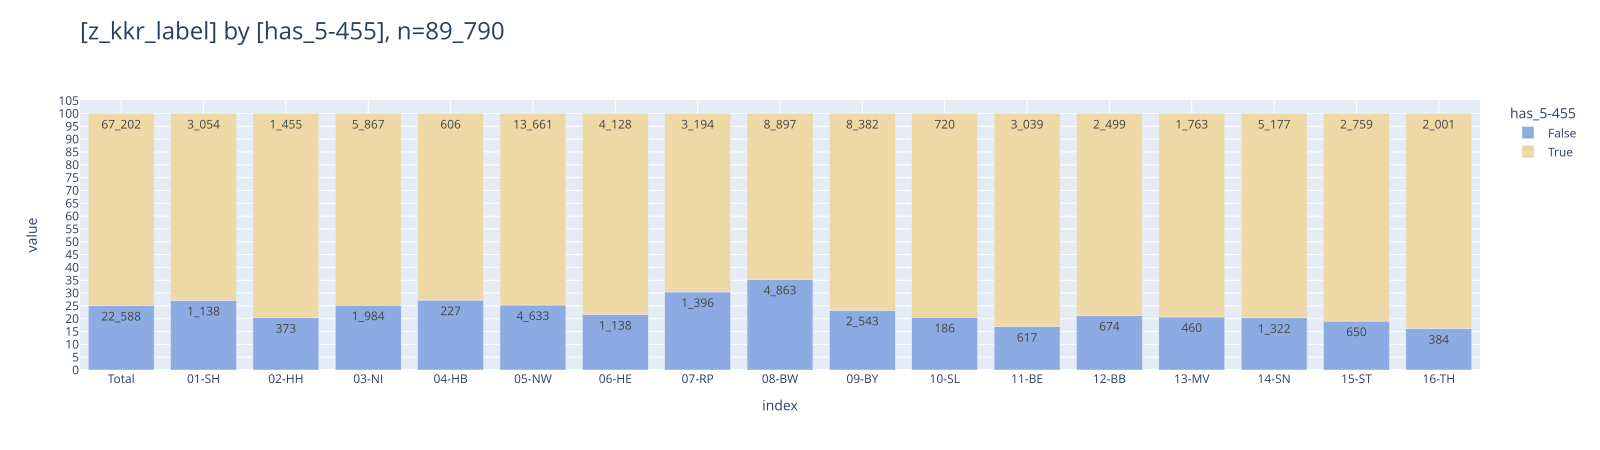

In [56]:
_filters_ops_5455 = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_NO_M1,
    FILTERS_M0,
]
_filter_ops_5455 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_ops_5455,
    # distinct_metric="OPSId",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) = '5-455')) as 'has_5-455',
        FROM (select * from Tumor where {_filter_ops_5455}) tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
)
_ = pls.plot_stacked_bars(
    _df,
    relative=True,
    show_total=True,
    orientation="v",
    height=450,
    color_palette=const.PALETTE_RKI2,
)

### <a id='toc1_5_4_'></a>[ Verteilung OPS 5-484 bei C20](#toc0_)
- Filter: `C18` und `M0`
- `has_5-48x`: True wenn Tumor >= 1 OPS 5-484 oder 5-485 hat
> 💡 ~40% haben True, weniger als erwartet 

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [ICD10 C20]:      n = 69_815  (30.7%) ░░░░░░░░░░░░░░░░░░░░░█████████
└ [nur M0]:         n = 40_980  (18.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_icd10_3d in ('C20')
and z_m_pc_1 = '0'
```

</details>

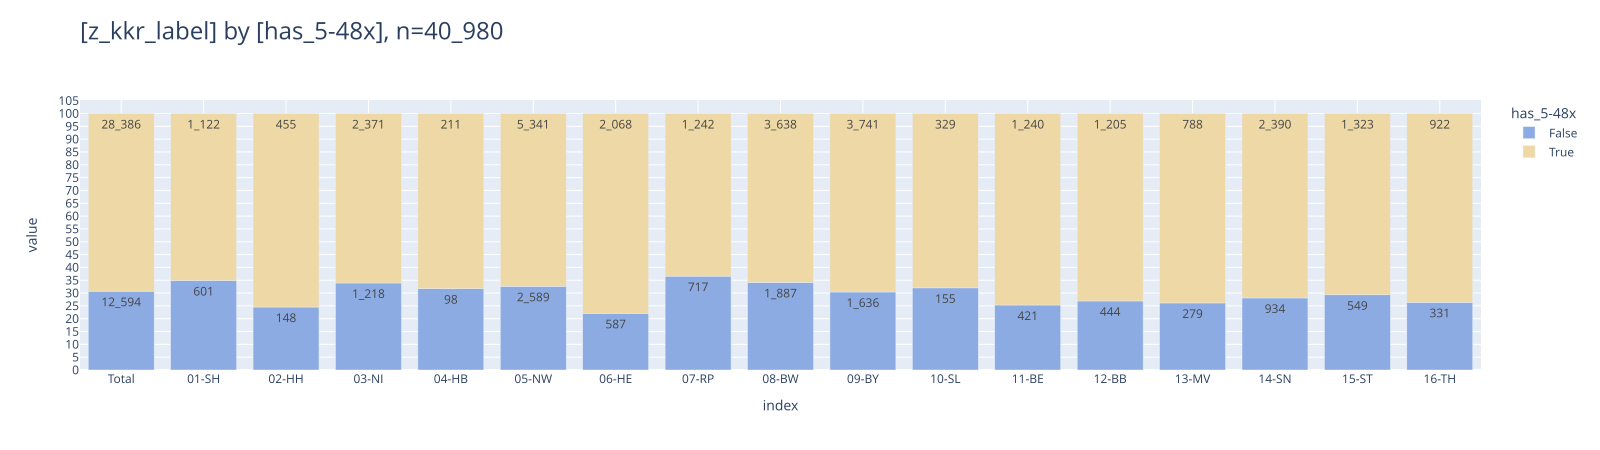

In [57]:
_filters_ops_5484 = [
    FILTERS_DY,
    FILTERS_C18C20,
    ("z_icd10_3d in ('C20')", "ICD10 C20"),
    FILTERS_M0,
]
_filter_ops_5484 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_ops_5484,
    # distinct_metric="OPSId",
    first_n_filter_apply_to_rows=2,
)

df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) in ('5-484', '5-485'))) as 'has_5-48x',
        FROM (select * from Tumor where {_filter_ops_5484}) tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
    
)
_ = pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="v",
    height=450,
    color_palette=const.PALETTE_RKI2,
    
)

### <a id='toc1_5_5_'></a>[Details OPS 5-455](#toc0_)


#### <a id='toc1_5_5_1_'></a>[Kombination von Gruppen](#toc0_)
- gezählt sind Tumore
- die Gruppen können überlappen bei der Tumordarstellung
  - `has_ileo` - Ileozökalresektion
  - `has_hemi` - rechte Hemikolektomie
  - `has_sigma` - Sigmaresektion
  - `has_robo_01` - OPS `5-987.01` (Roboter) ist Tumor zugeordnet

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401
└ [DJ 2020-2024]: n = 2_998_753
└ [nur C18]:      n = 154_219 (100.0%) ██████████████████████████████
└ [OPS 5-4]:       n = 99_862  (64.8%) ░░░░░░░░░░░███████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and left(Code,3) in ('5-4')
```

</details>

n = 99_862 | n(true) = 62_806


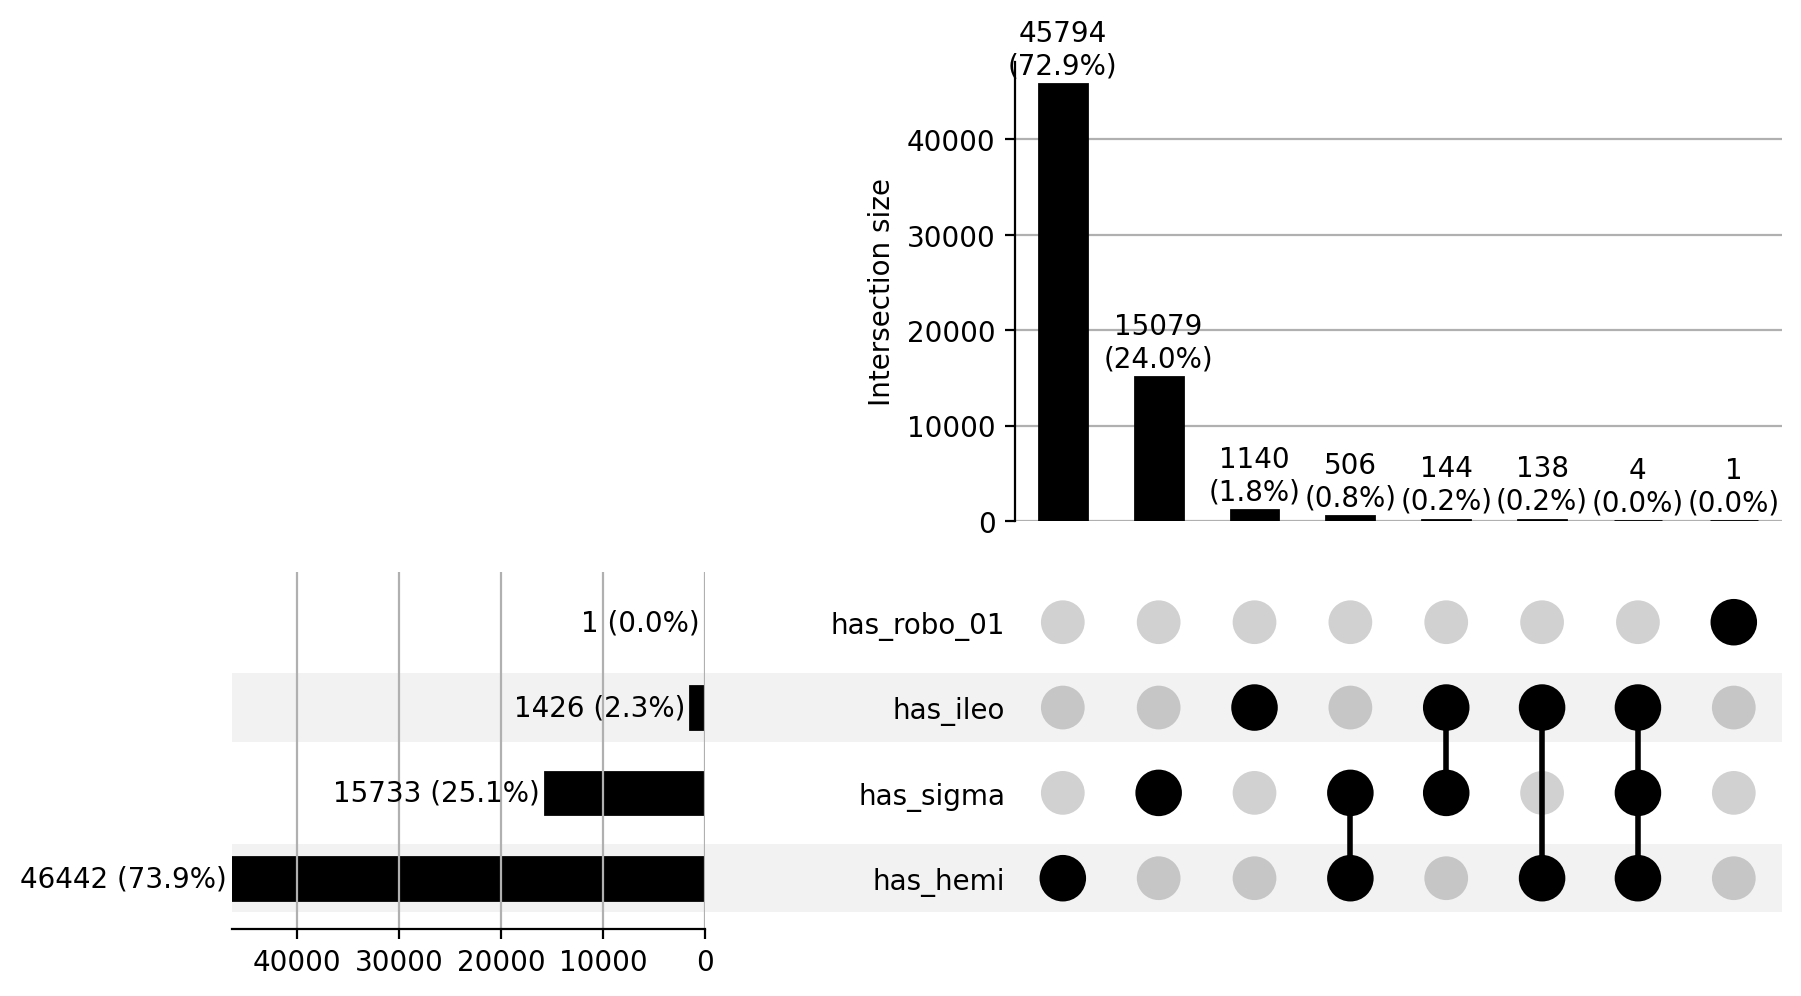

In [58]:
_filters = [
    FILTERS_DY,
    FILTERS_C18,
    FILTERS_OPS_54,
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters,
    first_n_filter_apply_to_rows=2,
    distinct_metric="z_tum_id",
)

_db = con.sql(f"""--sql
        select
            --OPId,
            tu.z_tum_id,
            ops.Code,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter}
""")


_db1 = con.sql("""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_dy::int as z_dy,
            z_kkr_label,
            case when left(ops.Code,7) in ('5-455.2') then true else false end as ileo,
            case when left(ops.Code,7) in ('5-455.4') then true else false end as hemi,
            case when left(ops.Code,7) in ('5-455.7') then true else false end as sigma,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_01,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where tu.z_tum_id in (select z_tum_id from _db)
    ), t2 as (
        select
            z_tum_id,
            z_dy,
            z_kkr_label,
            max(ileo) as has_ileo,
            max(hemi) as has_hemi,
            max(sigma) as has_sigma,
            max(robo_01) as has_robo_01,
            max(robo) as has_robo,
        from t1
        group by all
    )
    select * from t2
""")

_df1 = (_db1
    .project("columns('^has_')")
    .project("* exclude (has_robo)")
    .to_df()
)

# ? debug
# db_ops_upset.filter("has_robo_true").show()
# hlp.get_tum_details("6caa10cf-5ca9-445e-8081-c915f6fe71a4", con=con)

pls.plot_upset(_df1, include_false_subsets=False)

# todo OK ebenfalls bundesland aufteilen

In [59]:
# # todo OK robotik sammelcode aufteilen - einzelne robo ops senden. robotik seperat
# (
#     con.table("OPS")
#     .filter("left(Code,5) = '5-987' and z_tum_id in (select distinct z_tum_id from _db)")
#     .value_counts("Code")
#     .order('"count(Code)" desc')
#     .show()
# )

#### <a id='toc1_5_5_2_'></a>[Anteil Robotik](#toc0_)
- Metrik: Anteil Tumore mit `5-987` an allen Tumoren im Filter

In [60]:
_df2 = (con.sql("""--sql
    select 
        z_kkr_label,
        z_dy,
        sum(has_robo) as sum_cnt_robo,
        count(*) as cnt,
        sum_cnt_robo / cnt as pct_robo,
    from _db1
    group by all
    union
    select
        'Total' as z_kkr_label,
        z_dy,
        sum(has_robo) as sum_cnt_robo,
        count(*) as cnt,
        sum_cnt_robo / cnt as pct_robo,
    from _db1
    group by all
    union
    select
        z_kkr_label,
        'Total' as z_dy,
        sum(has_robo) as sum_cnt_robo,
        count(*) as cnt,
        sum_cnt_robo / cnt as pct_robo,
    from _db1
    group by all
    union
    select
        'Total' as z_kkr_label,
        'Total' as z_dy,
        sum(has_robo) as sum_cnt_robo,
        count(*) as cnt,
        sum_cnt_robo / cnt as pct_robo,
    from _db1
    group by all
    """)
    .to_df()
    [["z_dy", "z_kkr_label", "pct_robo"]]
)
# display(_df1)

display(tbl.pivot_df(
    _df2,
    total_axis="",
    pct_axis="",
    data_bar_axis="xy",
    heatmap_axis="",
    show_as_pct=True,
    precision=1,
    kpi_mode="max_min_x",
    swap=True,
    # total_exclude=True,
    # kpi_mode="rag_abs",
    # kpi_rag_list=[.95, .8],
    font_size_th=12,
    font_size_td=11,
    
))

z_dy,2020,2021,2022,2023,2024,Total
z_kkr_label,,,,,,
01-SH,2.8% ⬜,2.4% ⬜,3.3% ⬜,6.1% ⬜,0 🟥,3.7% ⬜
02-HH,3.6% 🟩,4.6% ⬜,4.4% ⬜,7.4% ⬜,0 🟥,5.0% ⬜
03-NI,0.8% ⬜,1.2% ⬜,2.7% ⬜,4.5% ⬜,0 🟥,2.1% ⬜
04-HB,0.4% ⬜,0 🟥,0.4% ⬜,0.5% ⬜,0 🟥,0.3% ⬜
05-NW,2.9% ⬜,5.1% ⬜,6.4% ⬜,9.7% ⬜,0 🟥,6.1% ⬜
06-HE,3.2% ⬜,4.2% ⬜,7.2% 🟩,10.9% 🟩,13.0% ⬜,6.4% 🟩
07-RP,1.5% ⬜,1.8% ⬜,5.8% ⬜,7.6% ⬜,0 🟥,3.9% ⬜
08-BW,1.4% ⬜,3.4% ⬜,5.2% ⬜,8.2% ⬜,0 🟥,4.5% ⬜
09-BY,1.5% ⬜,3.4% ⬜,4.5% ⬜,8.1% ⬜,7.1% ⬜,4.1% ⬜


#### <a id='toc1_5_5_3_'></a>[Ileozökalresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.2` aufweisen
- Gruppen
  - `5-455.21` - offen
  - `5-455.25` - laparoskopisch
  - `5-455.27` - konversion
  - `other` - sonstige, keine der genannten

<!-- > 💡 keine Robotik `5-987.1` geschlüsselt für diese Tumore -->

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [Tumor hat OP]:  n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [OPS ileo]:        n = 1_655   (0.7%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_tum_op_count > 0
and 
    z_tum_id in
        (select distinct z_tum_id from OPS where left(Code,7) in ('5-455.2'))
    
```

</details>

n = 1_655 | n(true) = 1_509


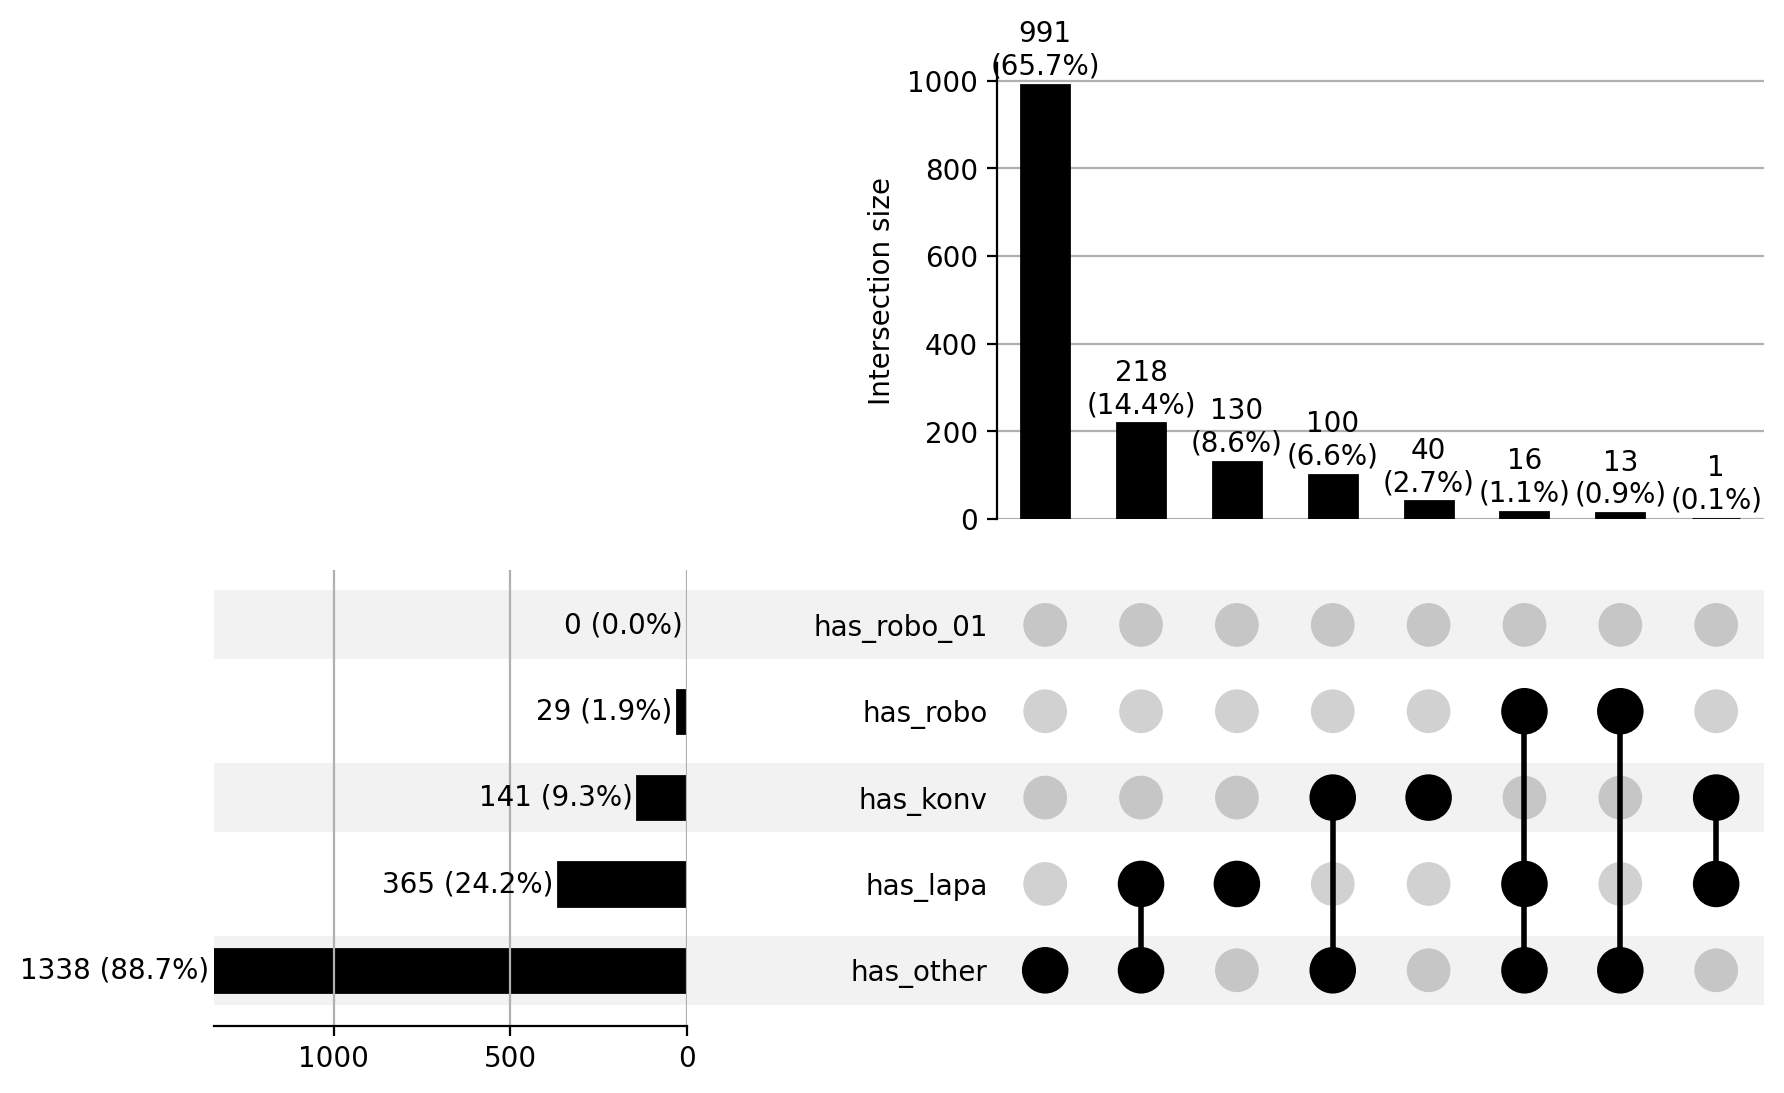

In [61]:
FILTERS_OPS_ILEO = ("""--sql
    z_tum_id in
        (select distinct z_tum_id from OPS where left(Code,7) in ('5-455.2'))
    """, "OPS ileo")
# FILTERS_OPS_ILEO = ("""--sql
#         (left(Code,7) in ('5-455.2'))
#     """, "OPS ileo")

_filters_ileo = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_HAS_OP,
    FILTERS_OPS_ILEO,
]
_filter_ileo=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_ileo,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4552 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.21') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.25') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.27') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_01,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
            case when not offen and not lapa and not konv then true else false end as other
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where tu.z_tum_id in (
            select distinct z_tum_id from Tumor where {_filter_ileo}
        )
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_01) as has_robo_01,
            max(robo) as has_robo,
            max(other) as has_other,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4552.filter("has_robo_01").show()

pls.plot_upset(db_ops_upset_4552.to_df().iloc[:,-5:],include_false_subsets=False)

# todo OK neue grupp "sonstige" für filter 5-455.2 neben 21/25/27

#### <a id='toc1_5_5_4_'></a>[rechte Hemikolektomie](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.4` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [Tumor hat OP]:  n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [OPS hemi]:       n = 49_413  (21.8%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_tum_op_count > 0
and 
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )
```

</details>

n = 49_413 | n(true) = 49_413


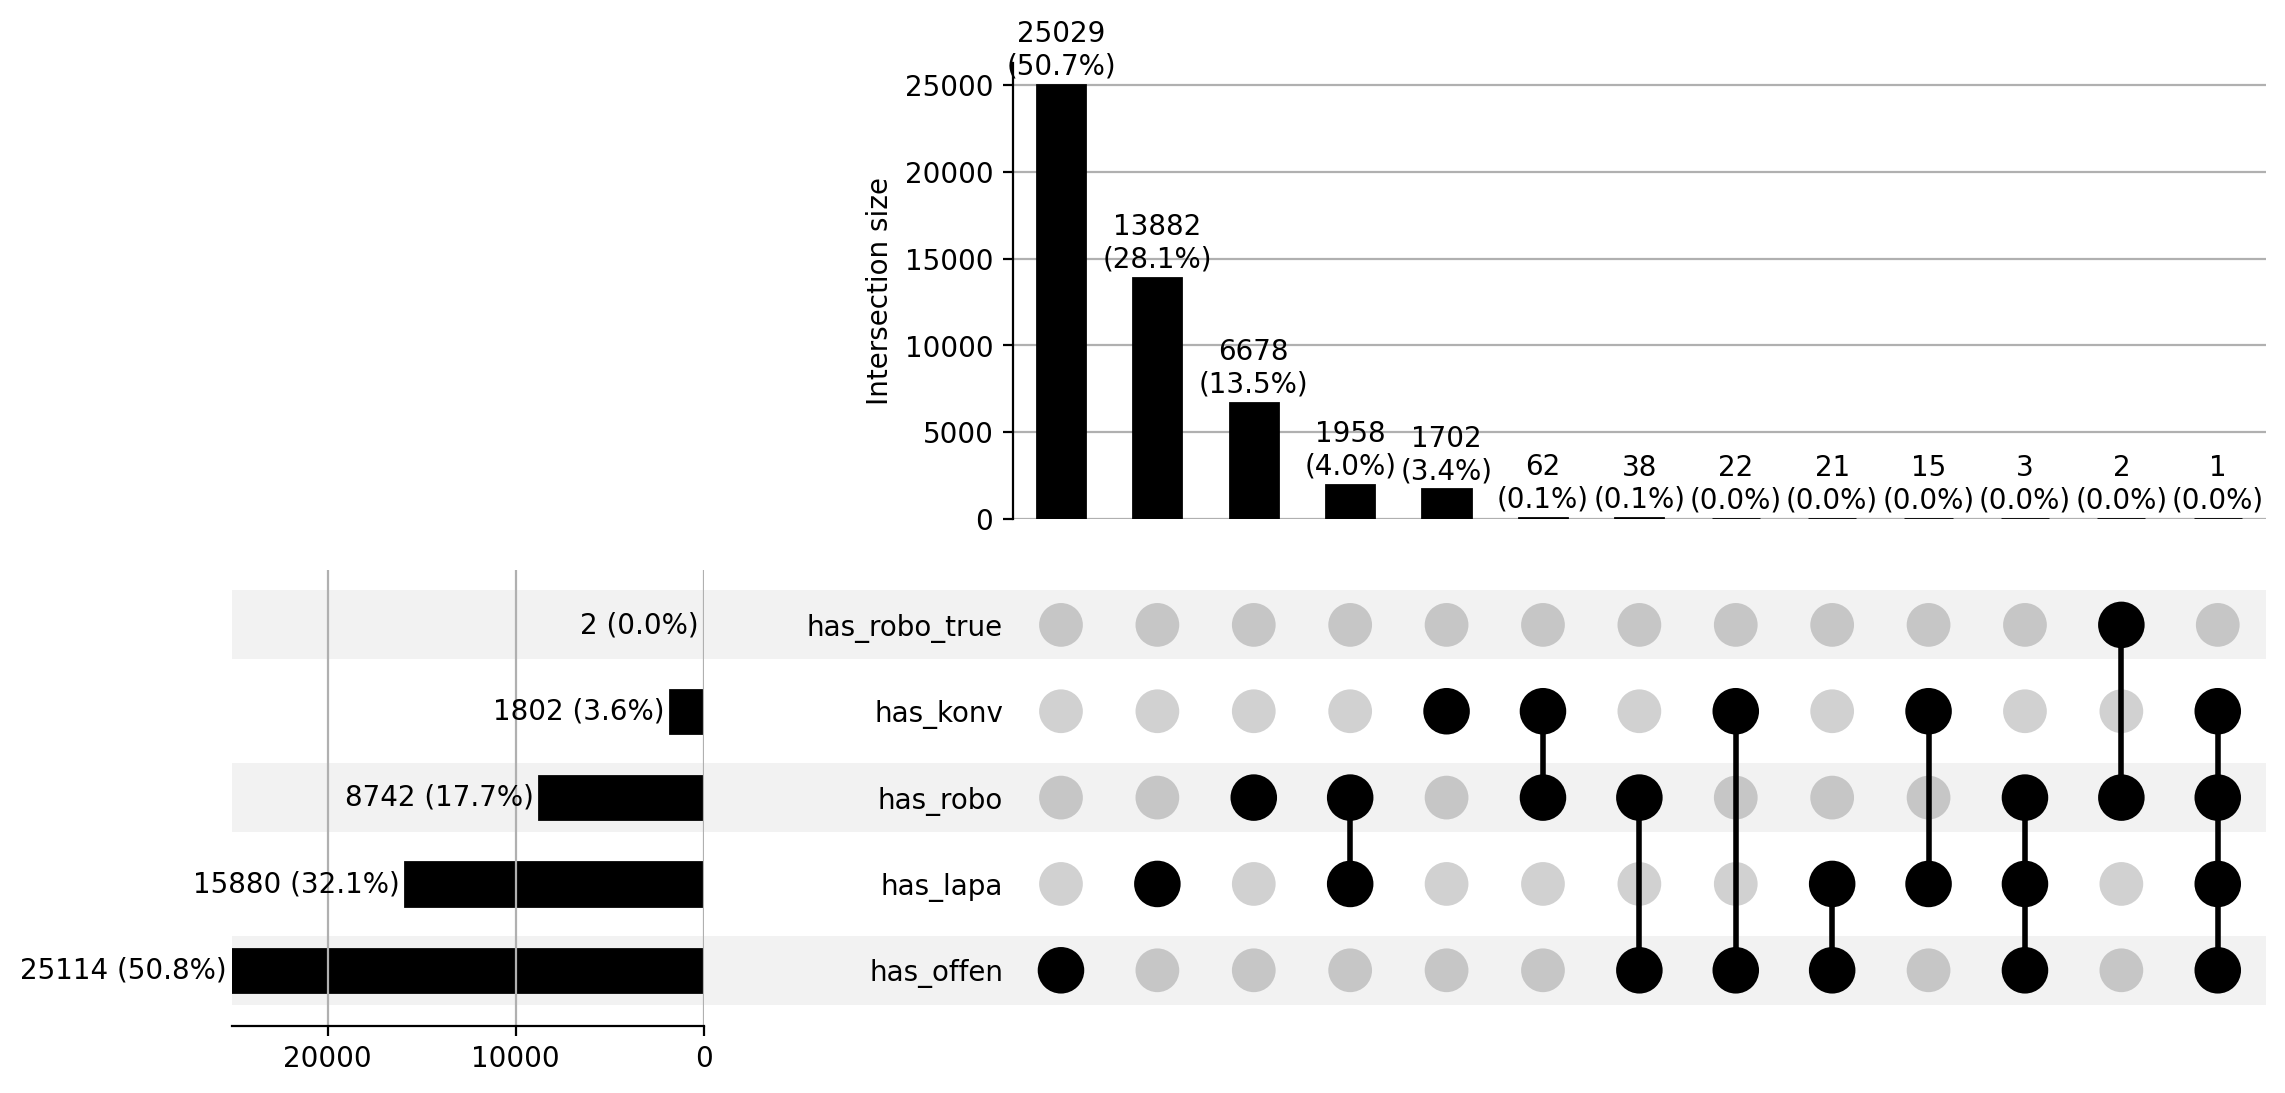

In [62]:
_filters_hemi = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_HAS_OP,
    FILTERS_OPS_HEMI,
]
_filter_hemi=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_hemi,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4554 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.41') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.45') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.47') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_hemi}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4554.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4554.to_df().iloc[:,-5:],include_false_subsets=False)

# todo anaolog oben

#### <a id='toc1_5_5_5_'></a>[Sigmaresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.7` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [Tumor hat OP]:  n = 147_189  (64.8%) ░░░░░░░░░░░███████████████████
└ [OPS sigma]:      n = 20_619   (9.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_tum_op_count > 0
and 
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )
```

</details>

n = 20_619 | n(true) = 20_619


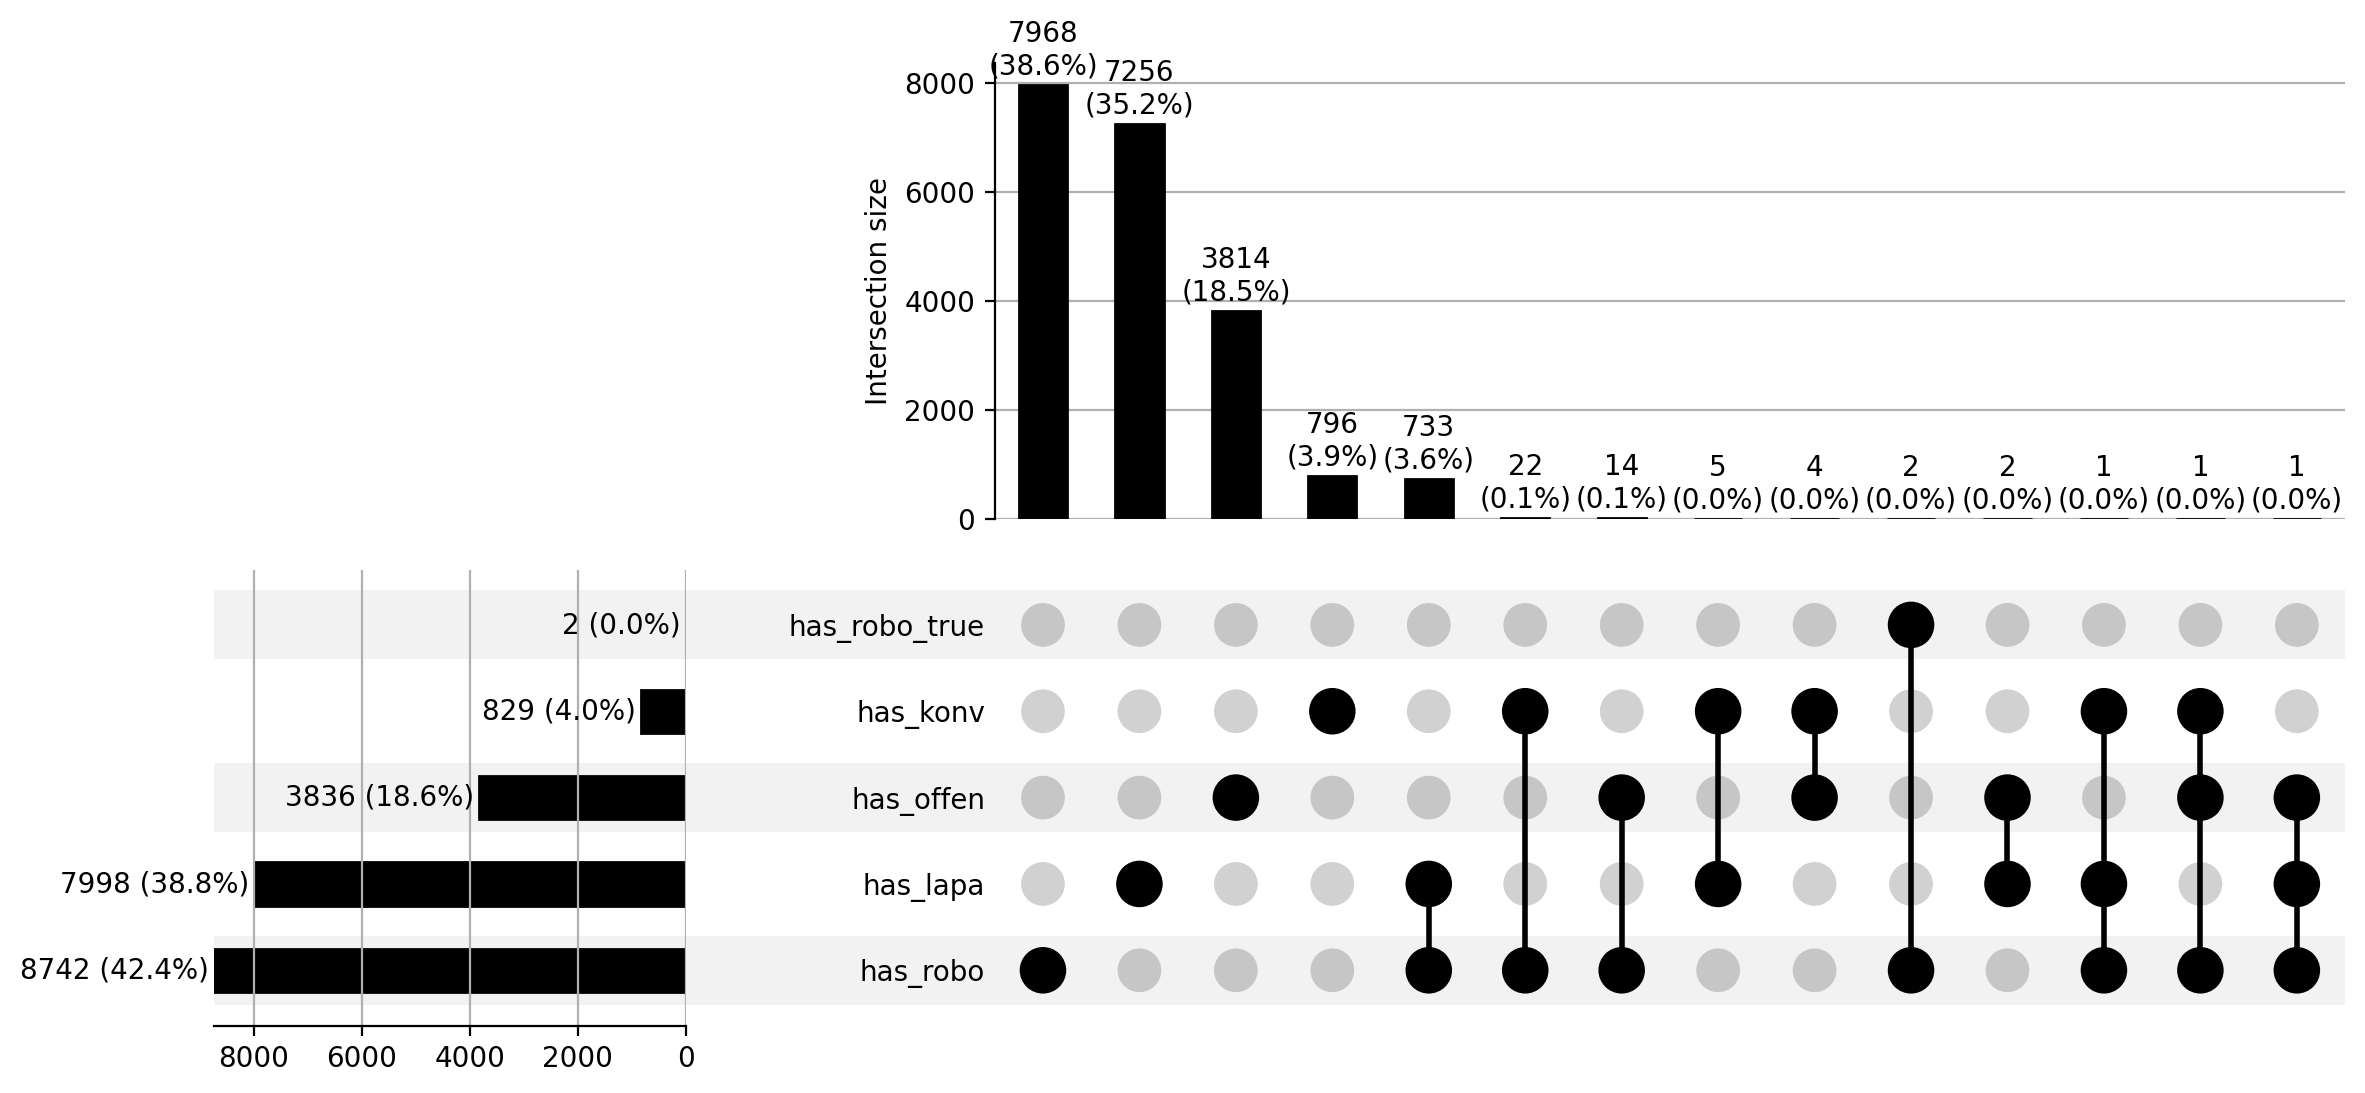

In [63]:
_filters_sig = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_HAS_OP,
    FILTER_OPS_SIG,
]

_filter_sig=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_sig,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4557 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.71') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.75') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.77') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_sig}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4557.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4557.to_df().iloc[:,-5:],include_false_subsets=False)

## <a id='toc1_6_'></a>[Lokalisation (Fernmetastasen) für C18](#toc0_)


### <a id='toc1_6_1_'></a>[nach M](#toc0_)
- gezählt sind Tumore
- M Angabe ist kombiniert aus pM (Vorrang) und cM
> 💡 45% von M1 haben Leber FM

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                   (100.0%) ██████████████████████████████
└ [DJ 2020-2024]: n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [nur C18]:        n = 154_219   (4.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
```

</details>

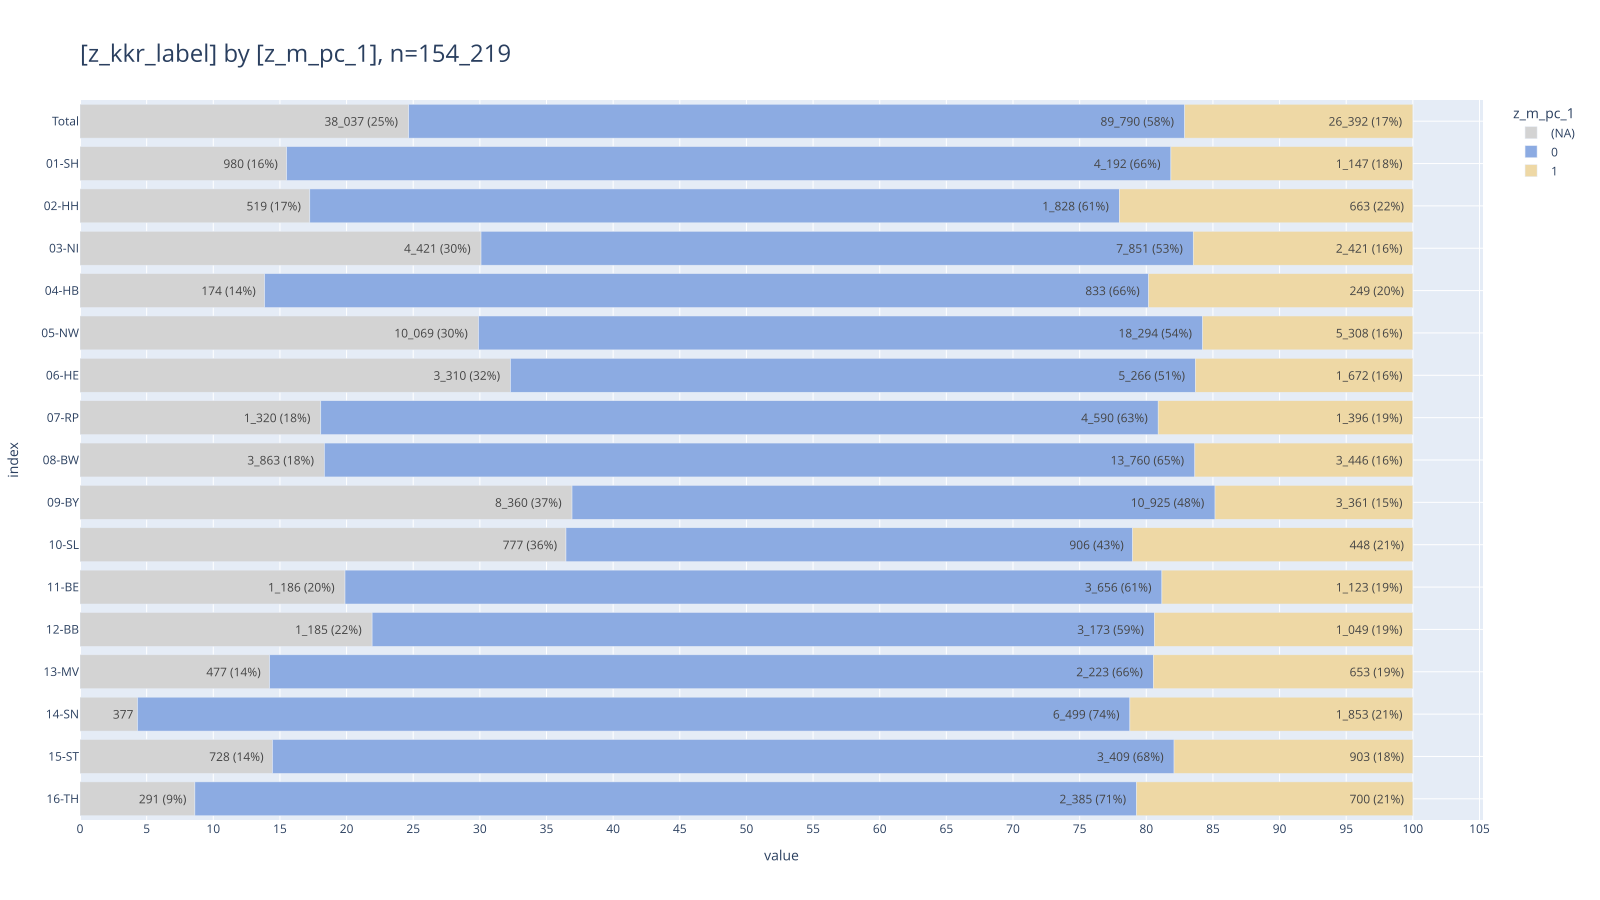

In [64]:
_filters = [
    FILTERS_DY,
    FILTERS_C18,
    # ("z_m_pc_1 in ('1')", "nur M1"),
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters,
    # distinct_metric="z_tum_id",
    # first_n_filter_apply_to_rows=2,
)


_df = (con.sql(f"""--sql
        SELECT
                z_kkr_label,
                --z_dy,
                z_m_pc_1,
        FROM  Tumor
        where {_filter}
    """)
    .to_df()
)
_ = pls.plot_stacked_bars(
    _df,
    relative=True,
    show_total=True,
    orientation="h",
    height=900,
    show_pct_bar=True,
    # color_palette="Pastel",
    color_palette=const.PALETTE_RKI2,
)
del _filter, _filters

### <a id='toc1_6_2_'></a>[Anteil FM Lokalisation Leber bei M1](#toc0_)
- gezählt sind Tumore
- `HEP` liegt vor, wenn für **Diagnose** oder **Folgeereignis** diese Lokalisation vermerkt ist
- Metrik: Anteil Tumore mit >=1 `HEP`

In [65]:

_filters = [
    FILTERS_DY,
    FILTERS_C18,
    ("z_m_pc_1 in ('1')", "nur M1"),
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters,
    # distinct_metric="z_tum_id",
    # first_n_filter_apply_to_rows=2,
)


_df = (con.sql(f"""--sql
    with t1 as (
        SELECT
            z_tum_id,
            z_kkr_label,
            z_dy::text as z_dy,
            case when {FILTERS_HEP[0]} then true else false end as has_hep,
        FROM  Tumor
        where {_filter}
    ),
    t2 as (
        select
            z_kkr_label,
            z_dy,
            sum(has_hep) as cnt_has_hep,
            count(*) as cnt,
            cnt_has_hep / cnt as pct_has_hep,
        from t1
        group by all
        union
        select
            'Total',
            z_dy,
            sum(has_hep) as cnt_has_hep,
            count(*) as cnt,
            cnt_has_hep / cnt as pct_has_hep,
        from t1
        group by all
        union
        select
            z_kkr_label,
            'Total',
            sum(has_hep) as cnt_has_hep,
            count(*) as cnt,
            cnt_has_hep / cnt as pct_has_hep,
        from t1
        group by all
        union
        select
            'Total',
            'Total',
            sum(has_hep) as cnt_has_hep,
            count(*) as cnt,
            cnt_has_hep / cnt as pct_has_hep,
        from t1
        group by all
    )
    select * from t2
    """)
    .to_df()
)
# _df
# _df
# _ = pls.plot_stacked_bars(
#     _df,
#     relative=True,
#     show_total=True,
#     orientation="h",
#     height=650,
#     show_pct_bar=True,
#     # color_palette="Pastel",
#     color_palette=const.PALETTE_RKI2,
# )
# del _filter, _filters

tbl.pivot_df(
    _df[["z_kkr_label", "z_dy", "pct_has_hep"]],
    show_as_pct=True,
    total_axis="",
    pct_axis="",
    precision=1,
    image_scale="80%",
)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                   (100.0%) ██████████████████████████████
└ [DJ 2020-2024]: n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [nur C18]:        n = 154_219   (4.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [nur M1]:          n = 26_392   (0.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and z_m_pc_1 in ('1')
```

</details>

<!-- SCALE-80% -->

z_dy,2020,2021,2022,2023,2024,Total
z_kkr_label,,,,,,
01-SH,63.5%,66.2%,66.0%,55.4%,0,62.9%
02-HH,63.9%,64.8%,59.9%,61.3%,0,62.4%
03-NI,65.4%,64.2%,62.1%,57.3%,0,62.4%
04-HB,65.7%,59.0%,66.7%,78.2%,0,67.1%
05-NW,53.3%,61.0%,61.9%,58.7%,0,58.7%
06-HE,71.1%,67.5%,68.0%,66.1%,55.6%,68.2%
07-RP,57.6%,50.8%,44.3%,17.8%,0,44.6%
08-BW,69.0%,68.7%,67.3%,66.9%,0,68.0%
09-BY,69.8%,71.8%,66.9%,62.6%,66.7%,68.0%


In [66]:
# hlp.get_tum_details("e40502bb-627b-44b7-b31f-f43e6ce283e9",con)

### <a id='toc1_6_3_'></a>[Behandlungsverlauf](#toc0_)
- gezählt sind Tumore
- beschränkt auf die ersten 5 Therapien
- Therapien mit gleichem Tumor / Datum / Behandlung sind zusammengeführt
- verschiedene Therapien mit gleichem Tumor und Datum sind hier nicht entfernt

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:                                           n = 2_998_753
└ [nur C18]:                                                n = 154_219 (100.0%) ██████████████████████████████
└ [nur M1]:                                                  n = 26_392  (17.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████
└ [Tumor mit HEP Lokalisation in FM Diagnose oder Verlauf]:  n = 17_141  (11.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [Tumor hat Therapie]:                                      n = 14_167   (9.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and z_m_pc_1 in ('1')
and 
    z_tum_id in (
        select distinct tum.z_tum_id
        from Tumor tum
        left join Diagnose_Fernmetastase dfm on tum.z_tum_id = dfm.z_tum_id
        left join Folgeereignis_Fernmetastase ffm on tum.z_tum_id = ffm.z_tum_id
        where (dfm.Lokalisation = 'HEP' or ffm.Lokalisation = 'HEP')
    )
and z_tum_op_count+z_tum_sy_count+z_tum_st_count > 0
```

</details>

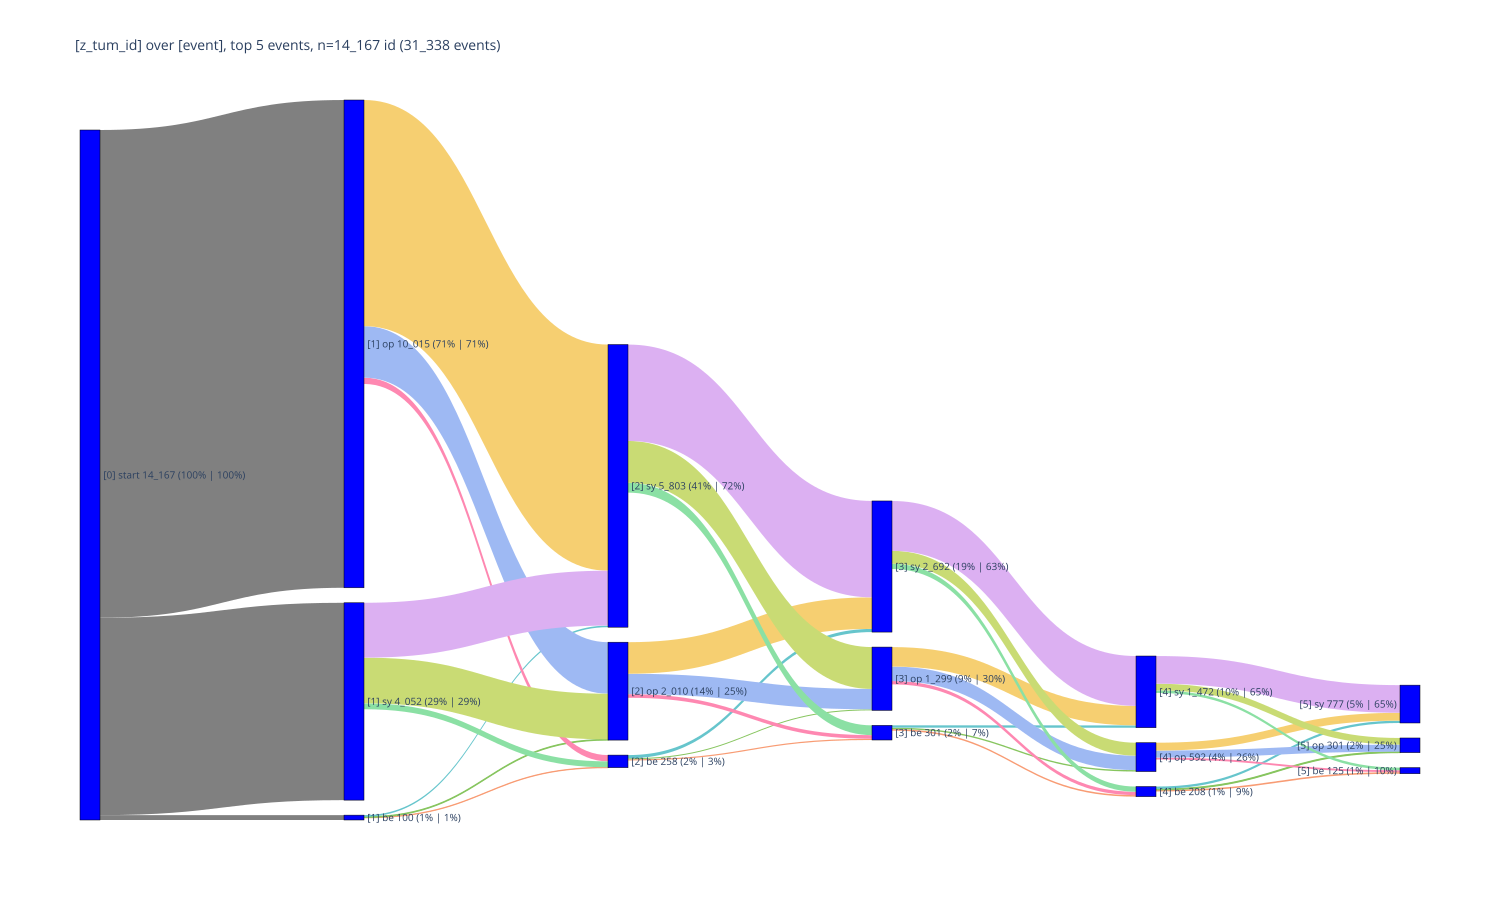

In [67]:
_filters = [
    FILTERS_DY,
    FILTERS_C18,
    ("z_m_pc_1 in ('1')", "nur M1"),
    FILTERS_HEP,
    FILTERS_HAS_TREAT,
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
    with t1 as (
        SELECT
            op.z_tum_id,
            op.Datum_OP,
            'op' as event
        FROM OP op
        where op.z_tum_id in
            (select distinct z_tum_id from Tumor where {_filter})
        union
        SELECT
            sy.z_tum_id,
            sy.Datum_Beginn_SYST,
            'sy' as event
        FROM SYST sy
        where sy.z_tum_id in
            (select distinct z_tum_id from Tumor where {_filter})
        union
        SELECT
            be.z_tum_id,
            be.Datum_Beginn_Bestrahlung,
            'be' as event
        FROM Bestrahlung be
        where be.z_tum_id in
            (select distinct z_tum_id from Tumor where {_filter})
    )
    select * from t1
    """)
    .to_df()
)

pls.plot_sankey(
    _df,
    max_events_per_id=5,
    # exclude_overlap_event=False,
    # exclude_overlap_id=False,
    height=900,
    width=1500,
    # palette_start=const.PALETTE_NA,
)
# todo wieviele betrifft das (gleiches Datum)

### <a id='toc1_6_4_'></a>[Erste Behandlung bei Leber FM](#toc0_)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:                                           n = 2_998_753
└ [nur C18]:                                                n = 154_219 (100.0%) ██████████████████████████████
└ [nur M1]:                                                  n = 26_392  (17.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████
└ [Tumor mit HEP Lokalisation in FM Diagnose oder Verlauf]:  n = 17_141  (11.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and z_m_pc_1 in ('1')
and 
    z_tum_id in (
        select distinct tum.z_tum_id
        from Tumor tum
        left join Diagnose_Fernmetastase dfm on tum.z_tum_id = dfm.z_tum_id
        left join Folgeereignis_Fernmetastase ffm on tum.z_tum_id = ffm.z_tum_id
        where (dfm.Lokalisation = 'HEP' or ffm.Lokalisation = 'HEP')
    )
```

</details>

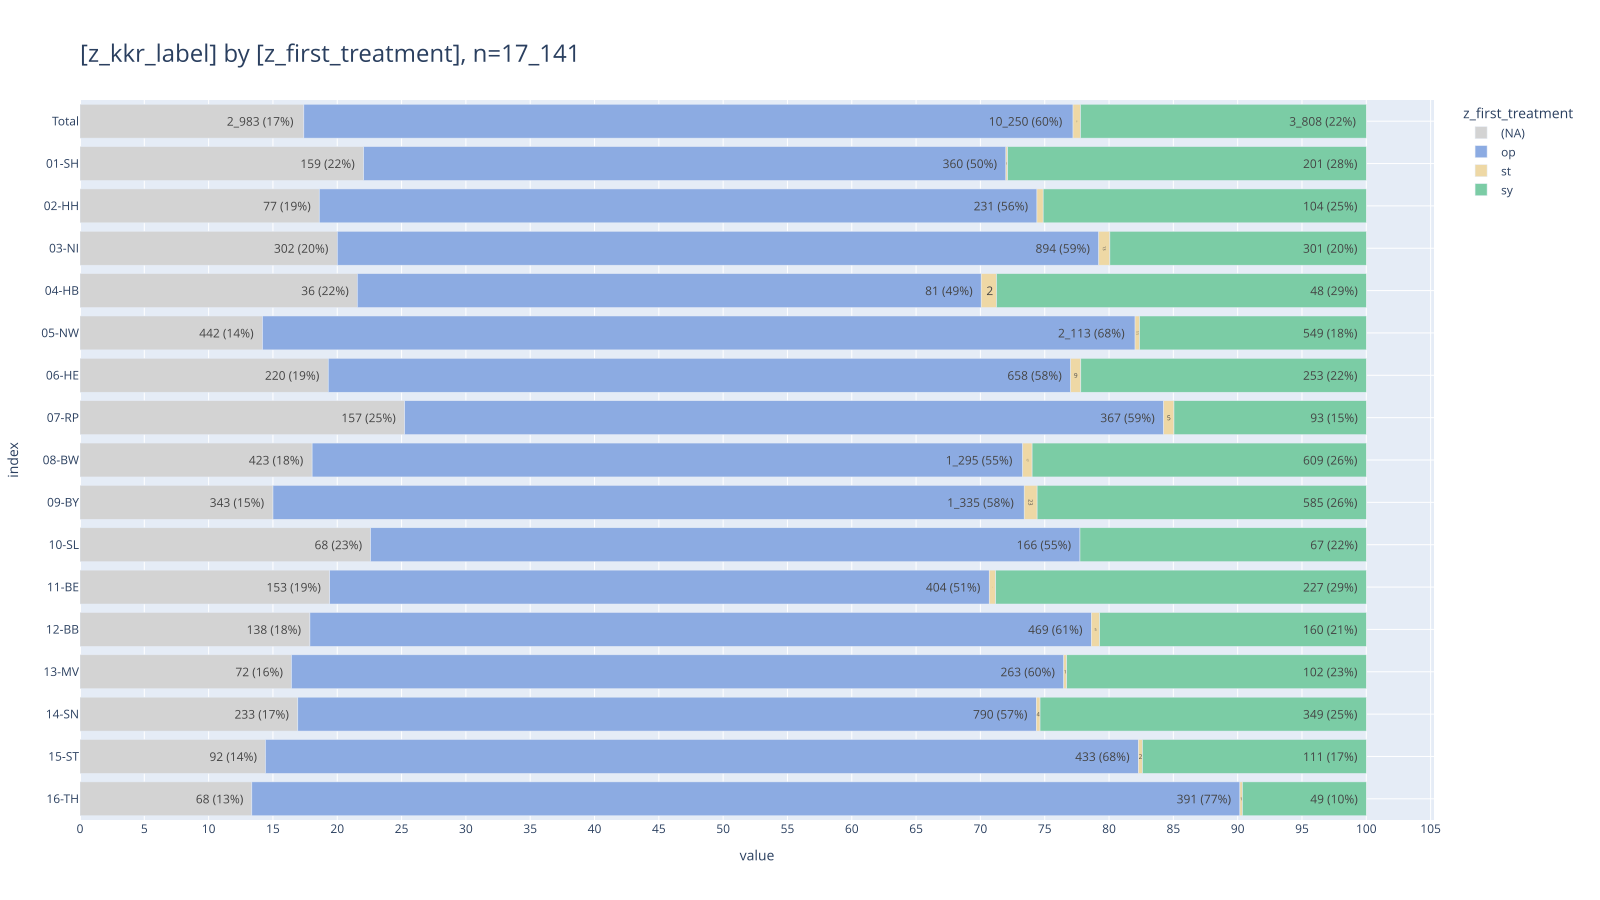

In [68]:
_filters = [
    FILTERS_DY,
    FILTERS_C18,
    ("z_m_pc_1 in ('1')", "nur M1"),
    FILTERS_HEP,
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
        SELECT
                z_kkr_label,
                --z_dy,
                z_first_treatment,
        FROM  Tumor tum
        --left join OP op on tum.z_tum_id = op.z_tum_id
        where {_filter}
    """)
    .to_df()
)
_ = pls.plot_stacked_bars(
    _df,
    relative=True,
    show_total=True,
    orientation="h",
    height=900,
    show_pct_bar=True,
    color_palette=const.PALETTE_RKI2,
)
del _filter, _filters

### <a id='toc1_6_5_'></a>[OPS wenn Erstbehandlung OPS](#toc0_)
- gezählt sind Tumore
- Kategorien OPS bei Erstbehandlung des Tumors
  - `1_other`: andere oder keine OPS
  - `2_colon`: erste 5 Stellen in `('5-455','5-484','5-485')`
  - `3_liver`: erste 5 Stellen in `('5-501','5-502','5-503')`
  - `4_both`: colon und liver geschlüsselt für Erstbehandlung

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:                                           n = 2_998_753
└ [nur C18]:                                                n = 154_219 (100.0%) ██████████████████████████████
└ [nur M1]:                                                  n = 26_392  (17.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████
└ [Tumor mit HEP Lokalisation in FM Diagnose oder Verlauf]:  n = 17_141  (11.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [Tumore mit OP als Erstbehandlung]:                        n = 10_250   (6.6%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and z_m_pc_1 in ('1')
and 
    z_tum_id in (
        select distinct tum.z_tum_id
        from Tumor tum
        left join Diagnose_Fernmetastase dfm on tum.z_tum_id = dfm.z_tum_id
        left join Folgeereignis_Fernmetastase ffm on tum.z_tum_id = ffm.z_tum_id
        where (dfm.Lokalisation = 'HEP' or ffm.Lokalisation = 'HEP')
    )
and z_first_treatment = 'op'
```

</details>

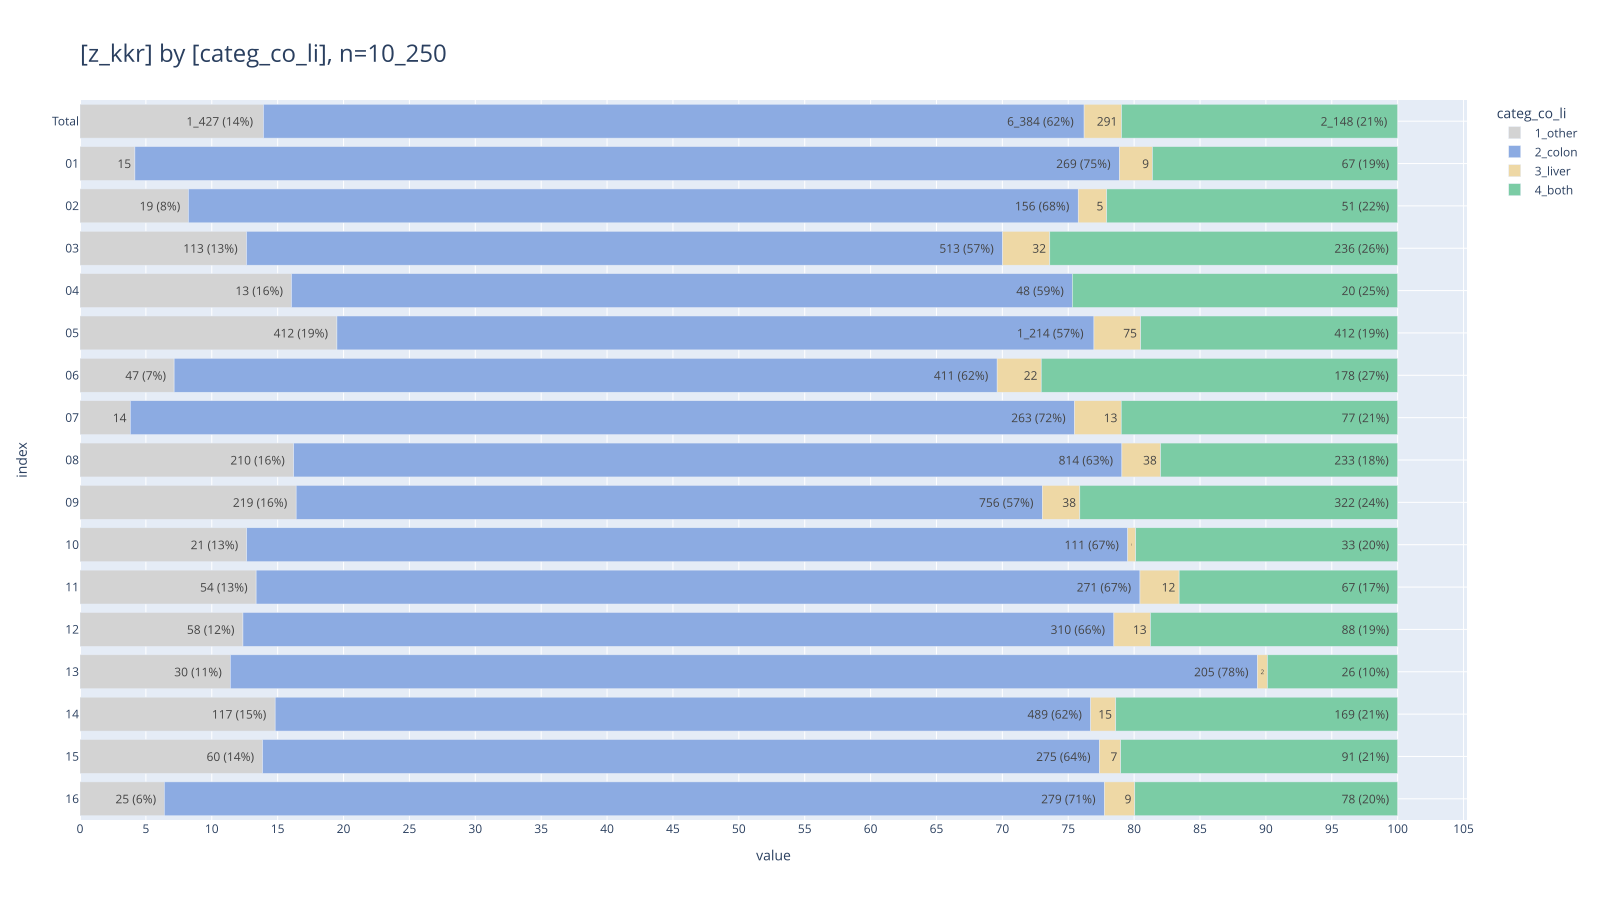

In [69]:
_filters = [
    FILTERS_DY,
    FILTERS_C18,
    ("z_m_pc_1 in ('1')", "nur M1"),
    FILTERS_HEP,
    ("z_first_treatment = 'op'", "Tumore mit OP als Erstbehandlung"),
]

_filter=hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
    with t1 as (
        SELECT
            op.z_tum_id,
            op.OPId,
            Code,
            coalesce(left(ops.Code,5) in ('5-455','5-484','5-485'),false) as is_colon_ops,
            coalesce(left(ops.Code,5) in ('5-501','5-502','5-503'),false) as is_liver_ops,
            op.Datum_OP,
            lpad(op.z_kkr::text,2,'0') as z_kkr
        FROM OP op
        left JOIN OPS ops on op.OPId = ops.OP_TypId
        where op.z_tum_id in
            (select distinct z_tum_id from Tumor where {_filter})
        and z_op_order = 1
    ),
    -- 1 op : 1 tum since only first OP is selected
    t2 as (
        SELECT
            --OPId,
            z_tum_id,
            max(is_colon_ops) as has_colon_ops,
            max(is_liver_ops) as has_liver_ops,
            case
                when not has_colon_ops and not has_liver_ops then '1_other'
                when has_colon_ops and not has_liver_ops then '2_colon'
                when not has_colon_ops and has_liver_ops then '3_liver'
                when has_colon_ops and has_liver_ops then '4_both'
            else 'U' end as categ_co_li,
            z_kkr,
            Datum_OP,
        FROM t1
        group by all
    )
    select * from t2
    """)
    .to_df()
)

_=pls.plot_stacked_bars(
    _df[["z_kkr", "categ_co_li"]],
    relative=True,
    show_total=True,
    orientation="h",
    height=900,
    show_pct_bar=True,
    color_palette=const.PALETTE_RKI2,
    # color_palette="Pastel",
    first_col_grey=True,
)

## <a id='toc1_7_'></a>[Rezidive](#toc0_)

### <a id='toc1_7_1_'></a>[Verteilung OP in 2020](#toc0_)
- Filter: `C18`-`C20`, 2020
- gezählt sind Tumore
- Einteilung der Verteilung in eine Kategorie Tabelle
  - `1_op_r0` - OP und R0 dokumentiert
  - `2_op_no_r0` - OP, kein R0
  - `3_no_op_but_pt` - keine OP, aber pT (Diagnose oder Verlauf)
  - `4_no_op_pt_but_st_sy` - keine OP, keine pT, aber ST oder SYST
  - `5_none` - keine Therapie oder pT


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [DJ 2020]:        n = 57_102  (25.1%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [nur C18]:        n = 38_714  (17.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_dy = 2020
and z_icd10_3d in ('C18')
```

</details>

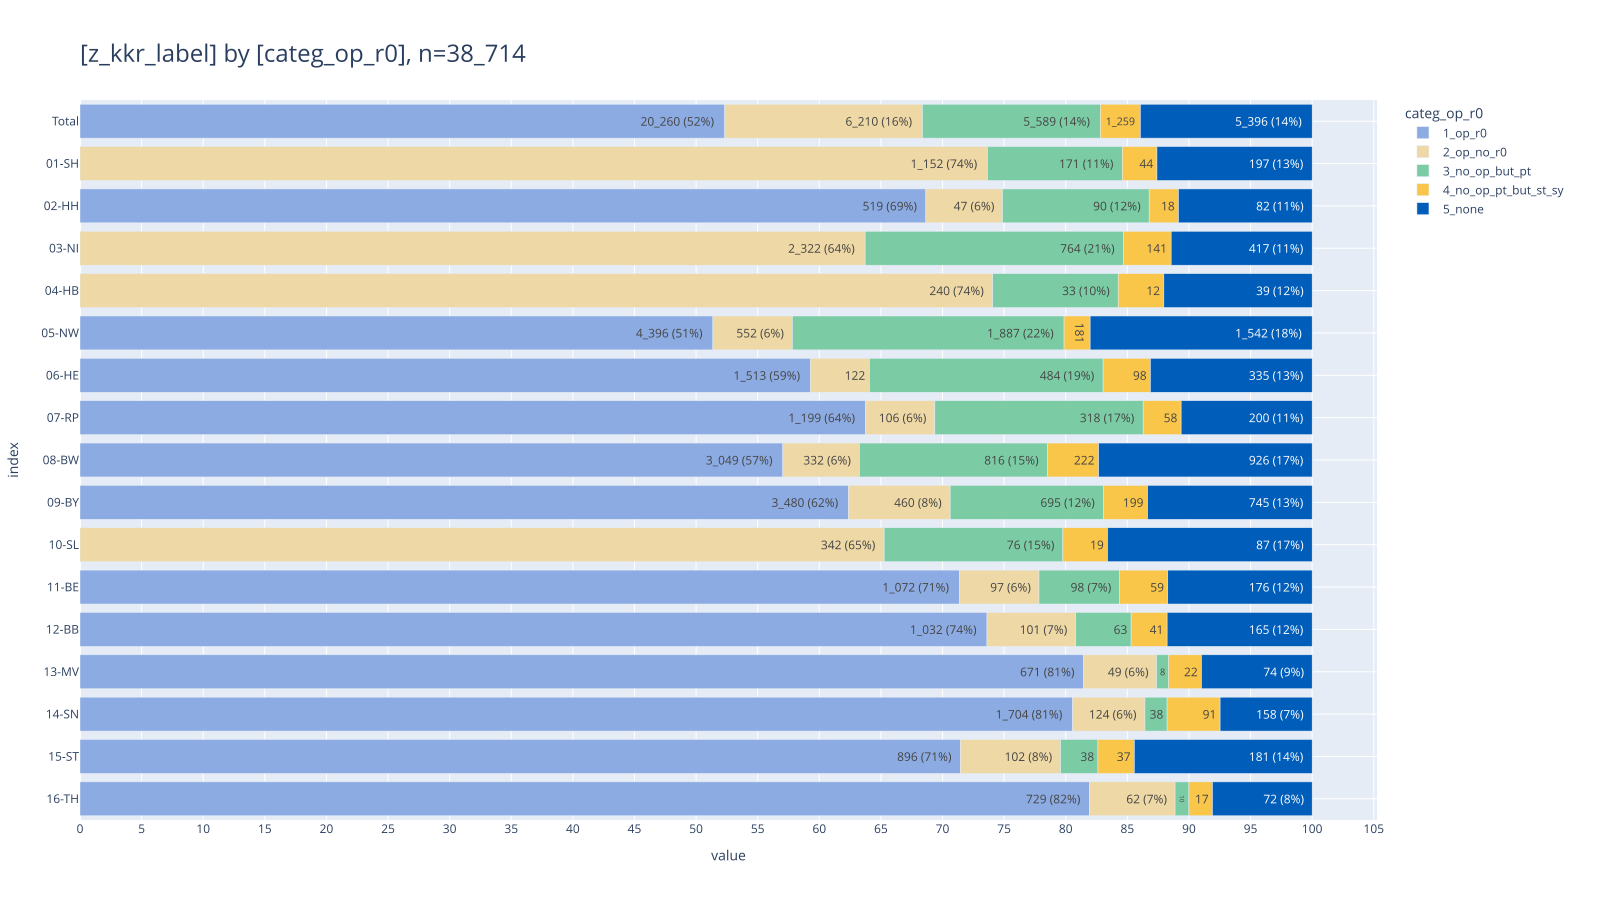

In [70]:

_filters_rez = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_2020,
    FILTERS_C18,
]

_filter_rez=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters_rez,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_r0 = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id,
                z_kkr_label,
                upper(left(op.Lokale_Beurteilung_Residualstatus,2)) as r_status,
                z_tum_op_count,
                z_tum_sy_count,
                z_tum_st_count,
                z_t_p_1 as pt_tum,
                case when
                    (ifnull(fo.T,'0') <> '0' and fo.c_p_u_Praefix_T = 'p')
                    or ifnull(z_t_p_1,'0') <> '0'
                    then true else false end as has_pt,
                case when z_tum_sy_count > 0 or z_tum_st_count > 0 then true else false end as has_st_sy,
                fo.T as t_fo,
                fo.c_p_u_Praefix_T as cpu_fo,
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join OP op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM fo on fo.z_tum_id = tum.z_tum_id
        where {_filter_rez}
    ),
    t2 as (
        select  z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                any_value(z_tum_op_count) as z_tum_op_count,
                any_value(z_tum_sy_count) as z_tum_sy_count,
                any_value(z_tum_st_count) as z_tum_st_count,
                max(ifnull(r_status,'')='R0') as has_r_status,
                max(has_st_sy) as has_st_sy,
                max(has_pt) as has_pt,
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  t2.*,
                case
                    when z_tum_op_count = 0 and not has_st_sy and not has_pt then '1_no_op_st_sy_pt'
                    when z_tum_op_count = 0 and not has_st_sy and has_pt then '2_no_op_st_sy_but_pt'
                    when z_tum_op_count = 0 and has_st_sy and not has_pt then '3_no_op_pt_but_st_sy'
                    when z_tum_op_count = 0 and has_st_sy and has_pt then '4_no_op_but_st_sy_pt'
                    when not has_r_status then '5_op_no_r0'
                    when has_r_status then '6_op_r0'
                    else '9_unknown'
                end as categ_op_r0__,
                case
                    when z_tum_op_count = 0 then '1_no_op'
                    when not has_r_status then '2_op_no_r0'
                    when has_r_status then '3_op_r0'
                    else '9_unknown'
                end as categ_op_r0_,
                case
                    when z_tum_op_count > 0 and has_r_status then '1_op_r0'
                    when z_tum_op_count > 0 and not has_r_status then '2_op_no_r0'
                    when has_pt then '3_no_op_but_pt'
                    when has_st_sy then '4_no_op_pt_but_st_sy'
                    when not has_st_sy then '5_none'
                    else '9_unknown'
                end as categ_op_r0,
        from t2
    )
    select * from t3
""")


pls.plot_stacked_bars(
    db_r0.project("z_kkr_label, categ_op_r0").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    # caption="tum_op_r0",
    height=900,
    width=1600,
    # color_palette="Pastel",
    color_palette=const.PALETTE_RKI2,
    # kkr_col="z_kkr_label"
    )
# tbl.pivot_df(db_r0.project("z_kkr_label, categ_op_r0").to_df(), swap=False, )

# todo grüner balken: welche pT steckt dahinter, welche OPS stecken dahinter top 30
# todo letzter balken: OK aufschlüsseln: M1? Alter? verstorben <180d nach diagnose? t?

### <a id='toc1_7_2_'></a>[M Stadium und Vitalstatus bei Tumoren ohne Therapie und pT](#toc0_)

n = 5_396


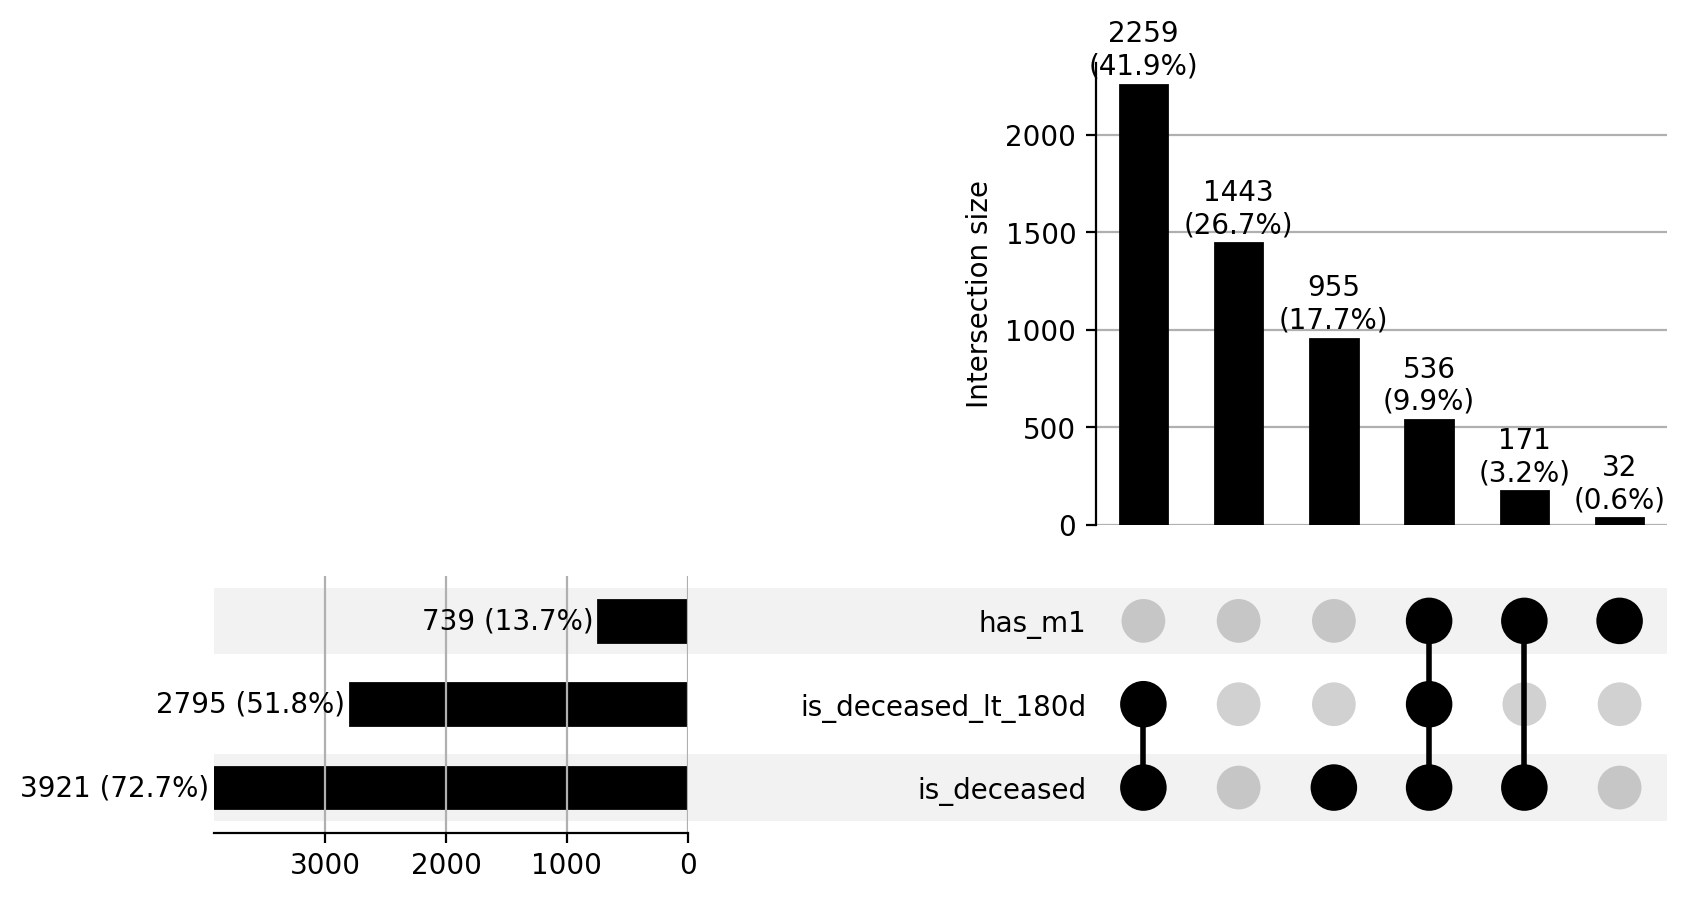

In [71]:
_df = (con.sql("""--sql
    select
        --tum.z_kkr_label,
        --z_m_pc_1,
        case when Verstorben = 'J' then true else false end as is_deceased,
        case when ifnull(tum.z_m_pc_1,'0') = '1' then true else false end as has_m1,
        case when ifnull(z_period_diag_death_day,181) < 180 then true else false end as is_deceased_lt_180d,
        --categ_op_r0
    from db_r0
    join Tumor tum on db_r0.z_tum_id = tum.z_tum_id
    join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
    where left(categ_op_r0,1) = '5'
    """)
    # .show()
    .to_df()
)
pls.plot_upset(_df,include_false_subsets=True)

### <a id='toc1_7_3_'></a>[R Status](#toc0_)
- `r_status`
  - `1_R0`: wenn >= 1 OP zum Tumor dokumentiert is mit `R0`
  - `2_R1_R2`: wenn kein `R0` dokumentiert, aber >= 1 OP mit `R1` oder `R2`
  - `3_NA_U_RX`: wenn beides nicht zutrifft (Feld ist leer, `U` oder `RX`)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:  n = 2_998_753
└ [ICD10 C18-C20]: n = 227_053 (100.0%) ██████████████████████████████
└ [DJ 2020]:        n = 57_102  (25.1%) ░░░░░░░░░░░░░░░░░░░░░░░███████
└ [nur C18]:        n = 38_714  (17.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
and z_dy = 2020
and z_icd10_3d in ('C18')
```

</details>

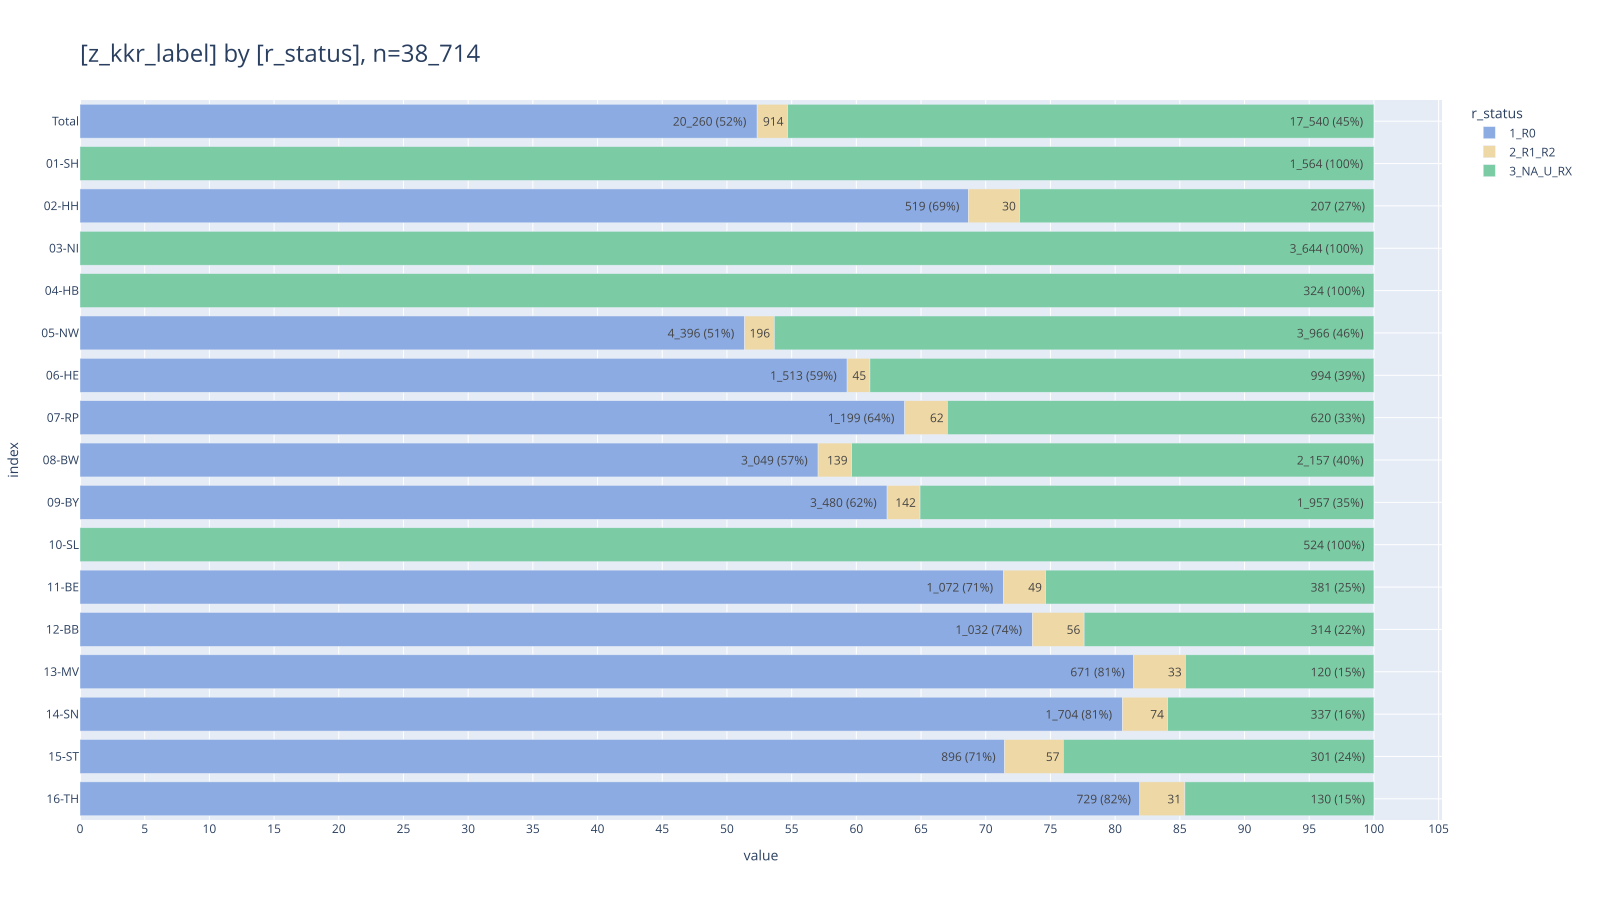

<!-- SCALE-40% -->

r_status,1_R0,2_R1_R2,3_NA_U_RX,Total
z_kkr_label,,,,
01-SH,0,0,1_564,1_564
02-HH,519,30,207,756
03-NI,0,0,3_644,3_644
04-HB,0,0,324,324
05-NW,4_396,196,3_966,8_558
06-HE,1_513,45,994,2_552
07-RP,1_199,62,620,1_881
08-BW,3_049,139,2_157,5_345
09-BY,3_480,142,1_957,5_579


In [72]:
_filters_rez = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_2020,
    FILTERS_C18,
]

_filter_rez=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters_rez,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_r0_2 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            case
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R0') then '1_R0'
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R1', 'R2') then '2_R1_R2'
                when
                    upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('RX')
                    or upper(left(ifnull(op.Lokale_Beurteilung_Residualstatus,'U'),1)) in ('U')
                    then '3_NA_U_RX'
                else 'U'
            end as r_status,
        from Tumor tum
        left join OP op on op.z_tum_id = tum.z_tum_id
        where {_filter_rez}
    ),
    t2 as (
        select
                z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                min(r_status) as r_status
        from t1
        group by z_tum_id
    )
    select * from t2
""")

pls.plot_stacked_bars(
    db_r0_2.project("z_kkr_label, r_status").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    # caption="op_r_status",
    height=900,
    width=1600,
    # kkr_col="z_kkr_label",
    color_palette=const.PALETTE_RKI2,
)

tbl.pivot_df(
    db_r0_2.project("z_kkr_label, r_status").to_df(),
    # swap=True,
    data_bar_axis="x",
    pct_axis="",
    total_exclude=True,
    font_size_th=9,
    font_size_td=7,
    image_scale="40%",
)

#### <a id='toc1_7_3_1_'></a>[davon: Verteilung nur R0](#toc0_)

**enge Definition eines Rezidivs** 
- Filter: lokaler Beurteilung Residualstatus = R0 (UND M <> 1)
- Rezidiv wenn  
  - Gesamtbeurteilung: Y  oder  
  - Lokaler Tumorstatus: R  oder  
  - Tumorstatus Lymphknoten:R oder  
  - Verlauf Fernmetastasen:R   

**erweiterte Definition (Verworfen)**
- Rezidiv wenn
  - (TNM)r_Symbol:r UND 
  - (Folgeereignis T>0 oder Folgeereignis N>0 oder Folgeereignis M>0)

**Diagramm**
- gezählt sind Tumore mit R0
- Kategorien
  - `1_fo_relapse` - Tumore mit Rezidiv nach enger Definition
  - `2_fo_relapse_tnm` - Tumore mit Rezidiv nach erweiterter Definition
  - `3_fo_no_relapse` - Tumore mit Folgeereignis ohne o.a. Rezidiv
  - `4_no_fo` - Tumore ohne Folgeereignis
- ℹ️ kkr mit "leerem Balken" nicht nicht in der Grundmenge enthalten, da sie keine R0 ausweisen

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 3_241_401
└ [DJ 2020]:           n = 741_531
└ [nur C18]:           n = 38_714 (100.0%) ██████████████████████████████
└ [Residualstatus R0]: n = 20_260  (52.3%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy = 2020
and z_icd10_3d in ('C18')
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
```

</details>

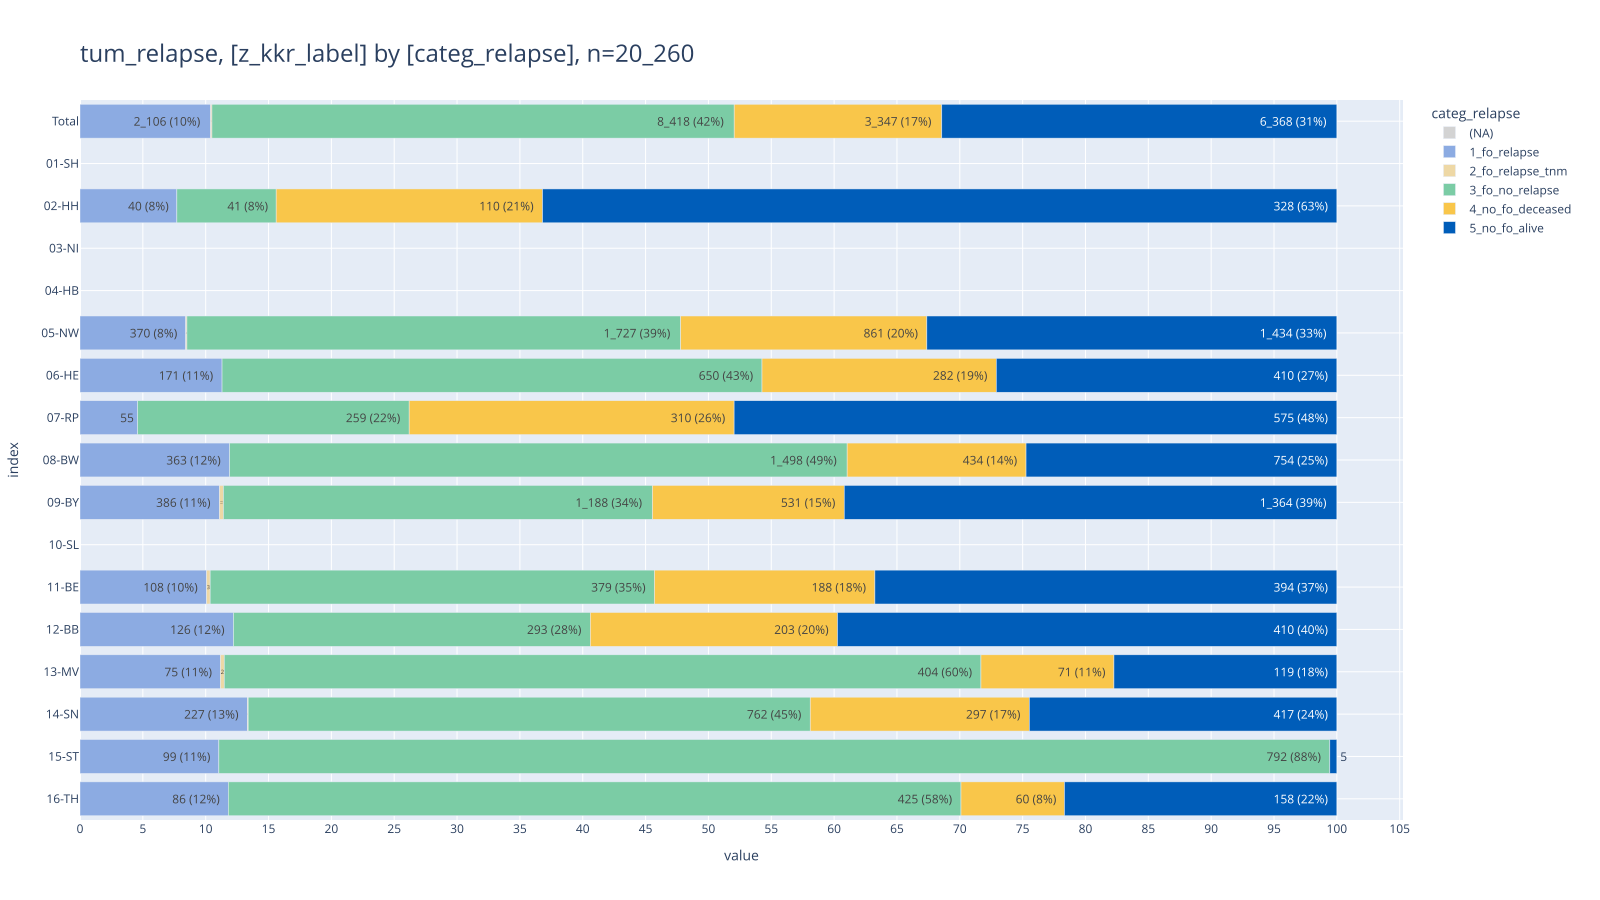

<!-- SCALE-50%, -->

categ_relapse,1_fo_relapse,2_fo_relapse_tnm,3_fo_no_relapse,4_no_fo_deceased,5_no_fo_alive,Total
z_kkr_label,,,,,,
02-HH,40,0,41,110,328,519
05-NW,370,4,1_727,861,1_434,4_396
06-HE,171,0,650,282,410,1_513
07-RP,55,0,259,310,575,1_199
08-BW,363,0,1_498,434,754,3_049
09-BY,386,11,1_188,531,1_364,3_480
11-BE,108,3,379,188,394,1_072
12-BB,126,0,293,203,410,1_032
13-MV,75,2,404,71,119,671


In [73]:
_filters_r0 = [
    FILTERS_2020,
    FILTERS_C18,
    FILTERS_R0,
    # FILTERS_M0,
]

_filter_r0=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OP op on op.z_tum_id = tum.z_tum_id
        """,
    filters=_filters_r0,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id
                ,z_pat_id
                ,fol.FolgeereignisId
                ,z_kkr_label
                ,z_m_pc_1
                ,fol.Gesamtbeurteilung_Tumorstatus
                ,fol.Verlauf_Lokaler_Tumorstatus 
                ,fol.Verlauf_Tumorstatus_Lymphknoten
                ,fol.Verlauf_Tumorstatus_Fernmetastasen
                ,r_Symbol
                ,T, N, M
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter_r0}
        --and ifnull(z_m_pc_1,'0') <> '1'
    ),
    t2 as (
        select  *
                ,(Gesamtbeurteilung_Tumorstatus ==  'Y') as has_gesamt
                ,(Verlauf_Lokaler_Tumorstatus == 'R') as has_lokal
                ,(Verlauf_Tumorstatus_Lymphknoten == 'R') as has_lymph
                ,(Verlauf_Tumorstatus_Fernmetastasen == 'R') as has_fm
                -- extended
                ,(r_Symbol is not null) as has_r_symbol
                ,(left(T,1) in ('1','2','3','4')) as has_t2plus
                ,(left(N,1) in ('1','2','3','4')) as has_n2plus
                ,(left(M,1) in ('1','2','3','4')) as has_m2plus
        from t1
    ),
    t3 as (
        select  z_tum_id
                ,first(z_pat_id) as z_pat_id
                ,first(FolgeereignisId) as FolgeereignisId
                ,first(z_m_pc_1) as z_m_pc_1
                ,first(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_gesamt)::text as has_gesamt
                ,max(has_lokal)::text as has_lokal
                ,max(has_lymph)::text as has_lymph
                ,max(has_fm)::text as has_fm
                ,max(has_r_symbol)::text as has_r_symbol
                ,max(has_t2plus)::text as has_t2plus
                ,max(has_n2plus)::text as has_n2plus
                ,max(has_m2plus)::text as has_m2plus
        from t2
        group by z_tum_id
    ),
    t4 as (
        select  t3.*
                ,pat.Verstorben
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) then true else false end as has_rel1
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) or ((has_t2plus or has_n2plus or has_m2plus)) then true else false end as has_rel2
                ,case 
                    when FolgeereignisId is not null and (has_gesamt or has_lokal or has_lymph or has_fm) then '1_fo_relapse'
                    when FolgeereignisId is not null and has_r_symbol and (has_t2plus or has_n2plus or has_m2plus) then '2_fo_relapse_tnm'
                    --when FolgeereignisId is not null and Verstorben = 'J' then '3_fo_deceased'
                    when FolgeereignisId is not null then '3_fo_no_relapse'
                    when FolgeereignisId is null and Verstorben = 'J' then '4_no_fo_deceased'
                    when FolgeereignisId is null and Verstorben = 'N' then '5_no_fo_alive'
                    else '9_unknown'
                end as categ_relapse
        from t3
        join Patient pat on pat.oBDS_RkiPatientId = t3.z_pat_id
    )
    select * from t4
""")
# tbl.descr_db(db_rez, "relapse")
n_tum = con.sql("select count(*) from db_rez").fetchone()[0]
# print(f"FILTER: {FILTER} | darin {n_tum:_} Tumore")

pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_relapse",
    height=900,
    width=1600,
    kkr_col="z_kkr_label",
    color_palette=const.PALETTE_RKI2,
    
)

tbl.pivot_df(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    swap=False,
    pct_axis="",
    image_scale="50%,"
)

# todo OK balken ohne fo näher betrachten: wer lebt noch aktuell?

<br>

## <a id='toc1_8_'></a>[Behandlung innerhalb von 6 Wochen](#toc0_)
- Filter: `C18`-`C20`
- `first_treatment_6w`
  - `<=6w`: erste Behandlung innerhalb von 6 Wochen
  - `>6w`: erste Behandlung nach 6 Wochen
  - `-`: keine Behandlung dokumentiert

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 2_998_753  (92.5%) ░░░███████████████████████████
└ [ICD10 C18-C20]:   n = 227_053   (7.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18', 'C19', 'C20')
```

</details>

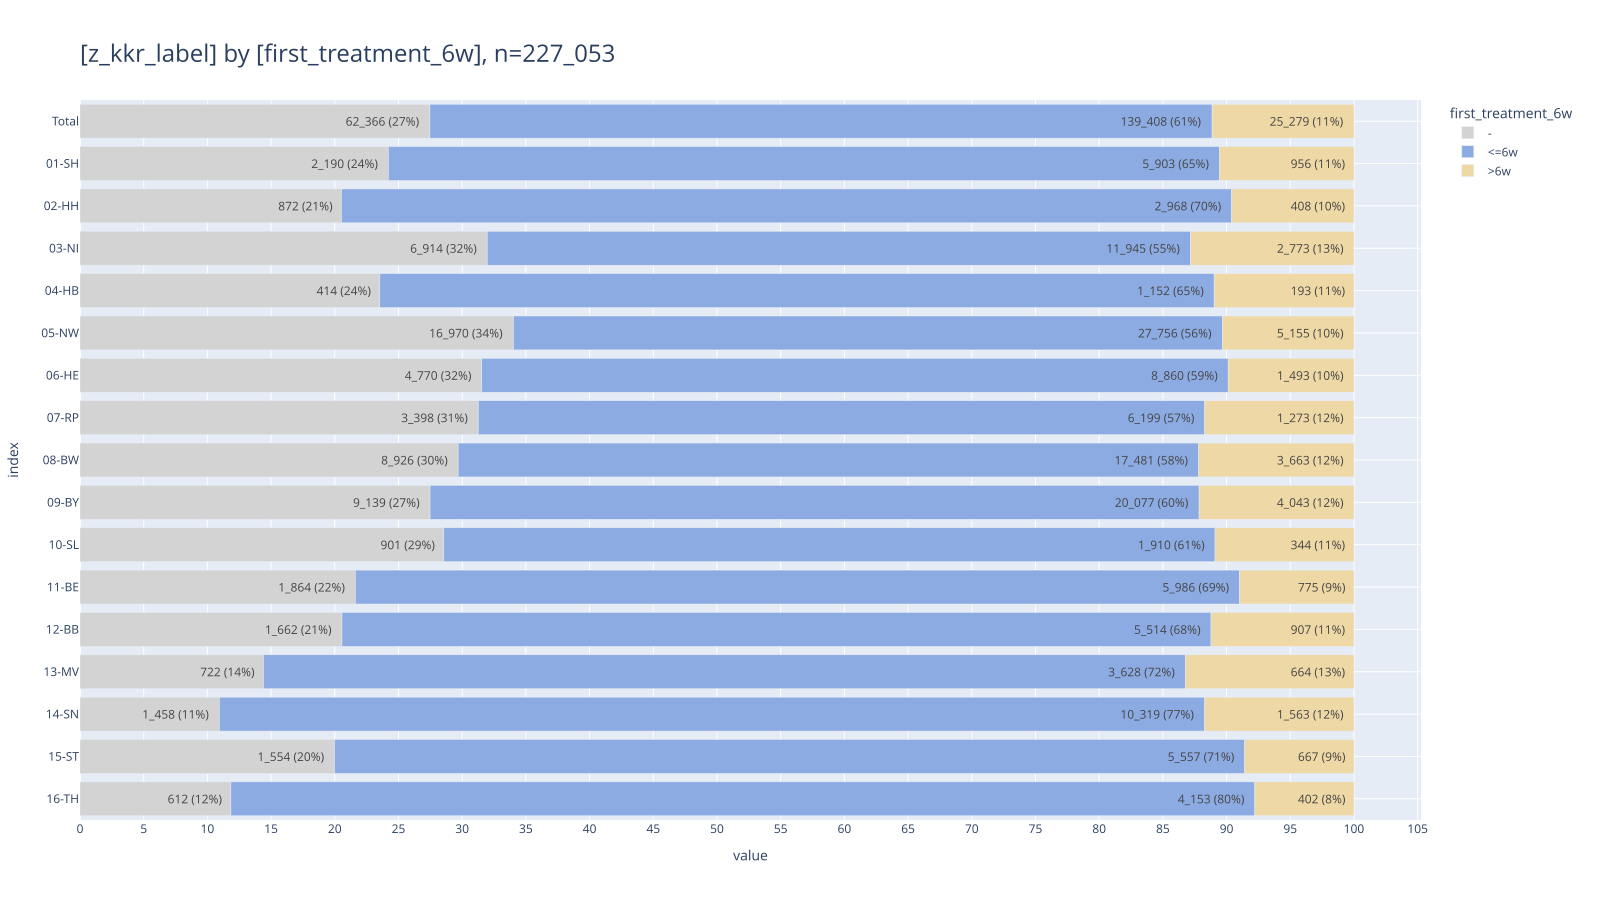

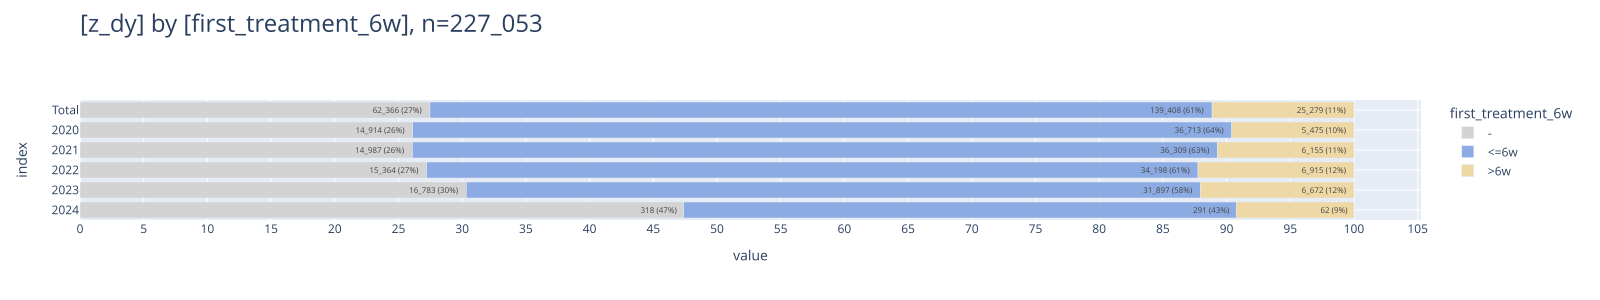

In [74]:
_filters_6w = [
    FILTERS_DY,
    FILTERS_C18C20,
]

_filter_6w=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        """,
    filters=_filters_6w,
    # distinct_metric="z_tum_id",
    # first_n_filter_apply_to_rows=2,
)

_df = con.sql(f"""--sql
    select
        tum.z_tum_id,
        tum.z_dy::text as z_dy,
        z_kkr_label,
        z_first_treatment_after_days,
        case
            when z_first_treatment_after_days is null then '-'
            when z_first_treatment_after_days < 43 then '<=6w'
            when z_first_treatment_after_days >= 43 then '>6w'
        else 'U' end
        as first_treatment_6w,
    from Tumor tum
    --left join OP op on op.z_tum_id = tum.z_tum_id
    where {_filter_6w}
""").to_df()

# display(_df)

_=pls.plot_stacked_bars(
    _df[["z_kkr_label", "first_treatment_6w"]],
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=900,
    show_pct_bar=True,
    first_col_grey=True,
    # color_palette="Pastel",
    color_palette=const.PALETTE_RKI2,
)
_=pls.plot_stacked_bars(
    _df[["z_dy", "first_treatment_6w"]],
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=300,
    show_pct_bar=True,
    first_col_grey=True,
    # color_palette="Pastel",
    color_palette=const.PALETTE_RKI2,
)

# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

### <a id='toc1_8_1_'></a>[Zeitlicher Abstand der Behandlungen](#toc0_)
- Filter: `C18`, Tumore mit Behandlung
- gezählt sind Tumore
- abgebildet sind Median Werte für den Abstand Diagnose bis erste Behandlung in Tagen (logarithmische Skala)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 3_241_401
└ [DJ 2020-2024]:       n = 2_998_753
└ [nur C18]:            n = 154_219 (100.0%) ██████████████████████████████
└ [Tumor hat Therapie]: n = 110_579  (71.7%) ░░░░░░░░░█████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and z_tum_op_count+z_tum_sy_count+z_tum_st_count > 0
```

</details>

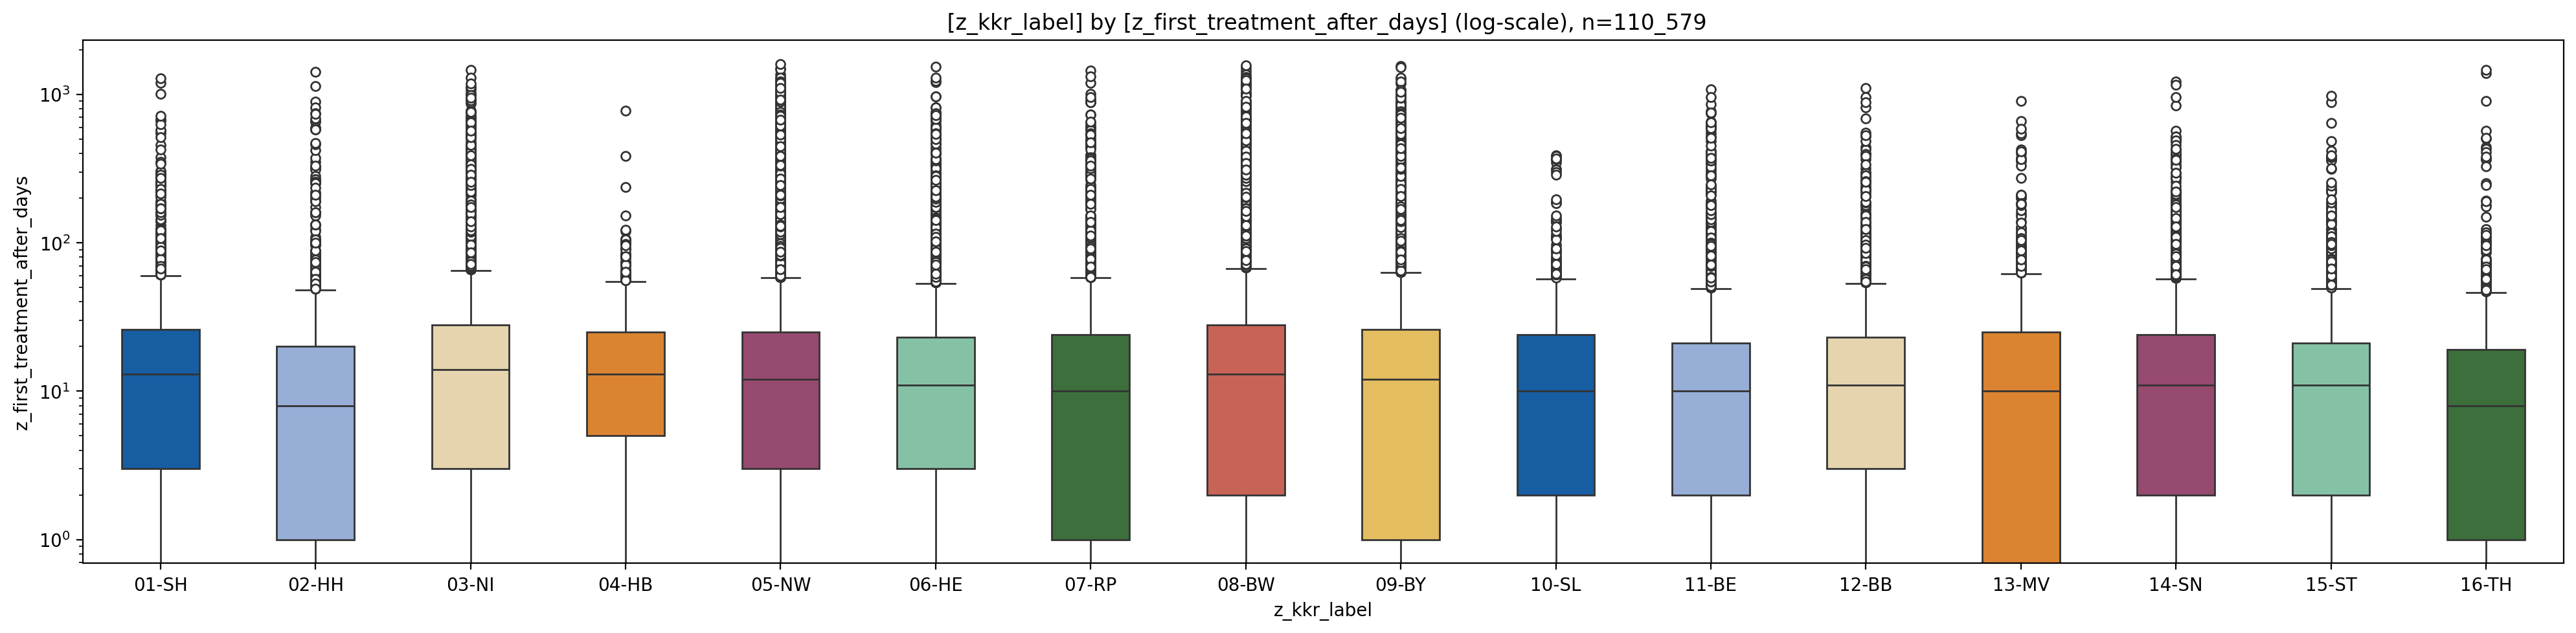


column (n = 110_579)         |    notnull    | min | lower | q25  | median | mean  |  q75  | upper |  max  |  std  |  cv 
-----------------------------+---------------+-----+-------+------+--------+-------+-------+-------+-------+-------+-----
z_first_treatment_after_days | 110_431 (99%) |   0 |     0 | 2.00 |  12.00 | 24.08 | 25.00 |    59 | 1_604 | 66.87 | 2.78


item (n = 110_579) | count  | min | lower | q25  | median | mean  |  q75  | upper |  max  |  std  |  cv 
-------------------+--------+-----+-------+------+--------+-------+-------+-------+-------+-------+-----
01-SH              |  4_768 |   0 |     0 | 3.00 |  13.00 | 21.30 | 26.00 |    60 | 1_279 | 48.67 | 2.28
02-HH              |  2_404 |   0 |     0 | 1.00 |   8.00 | 21.00 | 20.00 |    48 | 1_413 | 67.73 | 3.23
03-NI              |  9_781 |   0 |     0 | 3.00 |  14.00 | 26.30 | 28.00 |    65 | 1_464 | 67.27 | 2.56
04-HB              |    961 |   0 |     0 | 5.00 |  13.00 | 19.52 | 25.00 |    55 |   775 | 34.01 | 1.74
0

In [75]:
_filters_treat = [
    FILTERS_DY,
    FILTERS_C18,
    FILTERS_HAS_TREAT
]

_filter_treat=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        """,
    filters=_filters_treat,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_delay = con.sql(f"""--sql
    select
            z_kkr_label,
            z_first_treatment_after_days, 
            z_first_treatment
    from Tumor
    where {_filter_treat}
    """)
# tbl.descr_db(db_delay)

_ = pls.plot_boxes_large(
    # _df[["z_kkr_label", "z_first_treatment_after_days"]],
    db_delay.to_df().iloc[:,:2],
    height=500,
    width=2000,
    use_log=True,
)
#139477

<!-- ## <a id='toc1_9_'></a>[Behandlungsverlauf](#toc0_)
- Filter: `C18`, nur Tumore mit Therapie
- gezählt sind Tumore
- beschränkt auf die ersten 5 Therapien
- Therapien mit gleichem Tumor / Datum / Behandlung sind zusammengeführt
- verschiedene Therapien mit gleichem Tumor und Datum sind hier nicht entfernt -->

In [76]:
# _filters_track = [
#     FILTERS_DY,
#     FILTERS_C18,
#     FILTERS_HAS_TREAT,
# ]

# _filter_track=hlp.get_duckdb_filter_n(
#     con=con,
#     query="""--sql
#         from Tumor
#         """,
#     filters=_filters_track,
#     # distinct_metric="z_tum_id",
#     first_n_filter_apply_to_rows=2,
# )

# # _filter = f"""--sql
# #     {FILTER_DEFAULT}
# #     and z_icd10_3d in ('C18')
# # """
# db_sankey = con.sql(f"""--sql
#     with t1 as (
#         select  t.z_tum_id
#                 ,op.Datum_OP as date_op
#                 ,Datum_Beginn_SYST as date_sy
#                 ,Datum_Beginn_Bestrahlung as date_be
#         from    Tumor t
#         left join OP op on t.z_tum_id = op.z_tum_id
#         left join SYST sy on t.z_tum_id = sy.z_tum_id
#         left join Bestrahlung be on t.z_tum_id = be.z_tum_id
#         where {_filter_track}
#         --where z_dy >= 2020 and year(Datum_OP) >= 2020 and year(Datum_Beginn_SYST) >= 2020 and year(Datum_Beginn_Bestrahlung) >= 2020
#     ),
#     t2 as (
#         SELECT  *
#         FROM t1
#         --UNPIVOT (date FOR event IN (date_op AS 'op', date_sy AS 'sy', date_be AS 'be'))
#         UNPIVOT INCLUDE NULLS (
#             date -- This is the value column
#             FOR event IN (
#                 date_op AS 'op',
#                 date_sy AS 'sy',
#                 date_be AS 'be'
#             )
#         )
#     ),
#     t3 as (
#         SELECT  z_tum_id
#                 ,date
#                 ,event
#         FROM t2
#         -- de-duplicate
#         group by z_tum_id, date, event
#     )
#     select * from t3
# """)

# # tbl.descr_db(db_sankey,"sankey")

# n_tum = con.sql("""select count(distinct z_tum_id) from db_sankey""").fetchone()[0]
# n_tum_date = con.sql("""select count(distinct z_tum_id) from db_sankey where date is not null""").fetchone()[0]
# n_events = con.sql("""select count(*) from db_sankey""").fetchone()[0]
# n_events_date = con.sql("""select count(*) from db_sankey where date is not null""").fetchone()[0]

# print(f"{n_tum:_} Tumore mit {n_events:_} deduplizierten Therapien | davon mit Datum: {n_tum_date:_} Tumore, {n_events_date:_} Therapien")

# _df = db_sankey.to_df().dropna()
# pls.plot_sankey(_df, max_events_per_id=5, exclude_overlap_event=False,height=900, width=1600,)

<!-- ## <a id='toc1_10_'></a>[🕹️ interaktiv](#toc0_) -->

In [77]:
if False:
    import pygwalker as pyg

    spec = "config/pygwalker_spec_colo.json"
    nodes = [
        ("cnt_tum", "count(distinct z_tum_id)"),
        ("cnt_pat", "count(distinct z_pat_id)"),
        ("cnt_op", "count(distinct op_id)"),
        ("cnt_st", "count(distinct st_id)"),
        ("cnt_syst", "count(distinct syst_id)"),
    ]
    hlp.add_measures_to_pyg_config(spec, nodes=nodes)

    _ = pyg.walk(
        db_colon.to_df(),
        appearance=os.environ['THEME'],
        spec=spec,
        kernel_computation=True,
    )